# Final Semester Project - DEEP Reinforcements Learning
Dear students,<br> this is the template notebook. Please copy it by clicking on the "File" tab and then on "Save a copy into drive".

---
<br>

### Name and ID:
Student 1: Igor Nazarenko   ID: 322029158
<br>
Student 2: Yuval Amit   ID: 203839907
<br><br>
<img src="https://raw.githubusercontent.com/Farama-Foundation/Minigrid/master/minigrid-text.png">

### https://minigrid.farama.org/

# Pre-Requisit

## Installs

In [11]:
# %%capture
# !sudo apt-get update
# !sudo apt-get install -y xvfb ffmpeg freeglut3-dev
# !pip install 'imageio==2.4.0'
# !apt-get install python-opengl -y
# !apt install xvfb -y
# !pip install pyvirtualdisplay
# !pip install piglet
# !pip install gymnasium
# !apt-get install python-opengl -y
# !apt install xvfb -y
# !pip install -U --no-cache-dir gdown --pre
# !pip install minigrid

  Using cached piglet-1.0.0-py2.py3-none-any.whl.metadata (814 bytes)
  Using cached piglet_templates-1.3.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached MarkupSafe-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (4.0 kB)
Using cached piglet-1.0.0-py2.py3-none-any.whl (2.2 kB)
Using cached attrs-25.3.0-py3-none-any.whl (63 kB)
Using cached MarkupSafe-3.0.2-cp313-cp313-macosx_11_0_arm64.whl (12 kB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [piglet]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [gdown]m 6/11 [charset_normalizer]


### Installs for macOS - My edition

In [17]:
# !pip install --upgrade pip
# !pip install gymnasium==1.2.0 minigrid==3.0.0 imageio==2.4.0 pyvirtualdisplay
# !brew install ffmpeg
# !pip install 'imageio==2.4.0'
# !pip install pyvirtualdisplay
# !pip install piglet
# !pip install -U --no-cache-dir gdown --pre
# !pip install "imageio[pyav]"   # brings in the 'av' wheel which bundles FFmpeg libs
# !pip install imageio[ffmpeg]
# !pip install --upgrade imageio-ffmpeg

  Using cached imageio-2.4.0-py3-none-any.whl
  Attempting uninstall: imageio
    Found existing installation: imageio 2.37.0
    Uninstalling imageio-2.37.0:
      Successfully uninstalled imageio-2.37.0
==> Downloading https://formulae.brew.sh/api/formula.jws.json
==> Downloading https://formulae.brew.sh/api/cask.jws.json
To reinstall 7.1.1_3, run:
  brew reinstall ffmpeg
zsh:1: no matches found: imageio[ffmpeg]


## Imports

In [28]:
# Python built-ins
import os, csv, time, random, copy
from collections import deque, defaultdict
from typing import Optional, Tuple, Sequence
from pathlib import Path

# Visualization & I/O
import matplotlib.pyplot as plt
import imageio
from PIL import Image
import cv2
import base64

# IPython / Display
import pyvirtualdisplay
import IPython
from pyvirtualdisplay import Display
from IPython.display import HTML
from IPython import display as ipythondisplay

# Core libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Gym & MiniGrid
import gymnasium
import gymnasium as gym
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from gymnasium.wrappers import (
    TimeLimit,
    ResizeObservation,
    FrameStackObservation,
    RecordEpisodeStatistics,
)
from gymnasium.vector import SyncVectorEnv, AsyncVectorEnv

import minigrid
from minigrid.wrappers import (
    RGBImgObsWrapper,
    RGBImgPartialObsWrapper,
    FullyObsWrapper,
    ImgObsWrapper,
)
from minigrid.core.world_object import Goal

# Optional extras
import seaborn as sns

#### Activating the device we want to use for all kind of computers

In [2]:
# Automatically select device: MPS for macOS, CUDA for NVIDIA GPUs, or CPU as fallback
device = torch.device("mps" if torch.backends.mps.is_built() else "cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("mps" if torch.backends.mps.is_built() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Using device: {DEVICE}")

Using device: mps
Using device: mps


In [3]:
# Constants for the environemnt configuration do no change the values
highlight = False
render_mode = "rgb_array"

## Display utils
The cell below contains the video display configuration. No need to make changes here.

In [9]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)
display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()

# Introduction

For this project, you will work with environments from the [MiniGrid](https://minigrid.farama.org) framework. MiniGrid is designed to test and benchmark reinforcement learning algorithms, offering a diverse range of tasks with varying levels of complexity.

MiniGrid environments are built around the concept of a partially observable, grid-based world where an agent operates to achieve predefined objectives.

## **MultiRoom Environment**

You will work with the **Dynamic Obstacles** see docomentation [here](https://minigrid.farama.org/environments/minigrid/DynamicObstaclesEnv/). Dynamic Obstacles introduces a level of complexity beyond simple navigation tasks by requiring the agent to navigate around moving obstacles while reaching a goal. This environment features obstacles that change position or direction over time, creating a dynamic challenge that tests the agent's ability to adapt and make real-time decisions. It serves as an excellent testbed for reinforcement learning algorithms that require temporal reasoning, prediction, and reactive planning in non-stationary environments.



## Understanding the `done` and `truncated` Mechanisms in `DynamicObstacles`

As you experienced in the MidTerm assignment, the **GYM** API returns multiple outputs from the **`step`** method. In the `DynamicObstacles` environment, two key mechanisms, **`done`** and **`truncated`**, are used to signify the end of an episode. These mechanisms are essential for managing the flow of training and providing valuable feedback about the agent's performance.


### `done`
- The `done` flag is set to `True` when the agent successfully reaches the goal.
- It indicates the successful termination of the episode, meaning the agent has completed the task.
- Example scenario: The agent navigates through all the rooms and reaches the green goal square in the final room.

### `truncated`
- The `truncated` flag is used to terminate an episode when a predefined condition is met, such as exceeding the maximum number of steps allowed.
- It does not necessarily indicate success or failure, but rather ensures that episodes do not run indefinitely.
- Example scenario: The agent fails to reach the goal within the allowed number of steps, and the episode ends prematurely.

**Pay Attention!**

Each time the environment is reset, the configuration of the rooms is randomized. This variability should be carefully considered during training, as resetting the environment every time the `max_step` limit is reached can make it challenging for the agent to learn effectively.

Additionally, note that the `max_step` parameter is defined as the number of rooms multiplied by 20.


## Random Action Rendering

In [12]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
video_filename = './content/vid.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=16) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not truncated:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(env.render())
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

done reward= 0 num_of_steps= 1024


## Wrappers for Observations: ImgObsWrapper and RGBImgPartialObsWrapper

For this project, you will use two wrappers provided by MiniGrid: **ImgObsWrapper** and **RGBImgPartialObsWrapper**. These wrappers modify the agent's observations.

### ImgObsWrapper
- The **ImgObsWrapper** converts the observation from its default dictionary format into a single image array.
- By default, observations in MiniGrid are returned as a dictionary containing both image data and other optional keys (e.g., mission strings). This wrapper extracts only the image component for simplicity.

### RGBImgPartialObsWrapper
- This wrapper provides a **partial view of the environment**, but instead of limiting it to a fixed field of view, it shows the **entire visible content of the current room** from the agent's position to the walls in the direction the agent is facing.
- The observation dynamically updates as the agent moves or turns, allowing it to see the layout of the room but not beyond its walls or through closed doors.
- This introduces the challenge of **partial observability across multiple rooms**, as the agent must explore and navigate to new rooms to gather more information about the environment.





### Wrapper Usage
To apply a wrapper, you can modify your environment setup as follows:

(56, 56, 3)


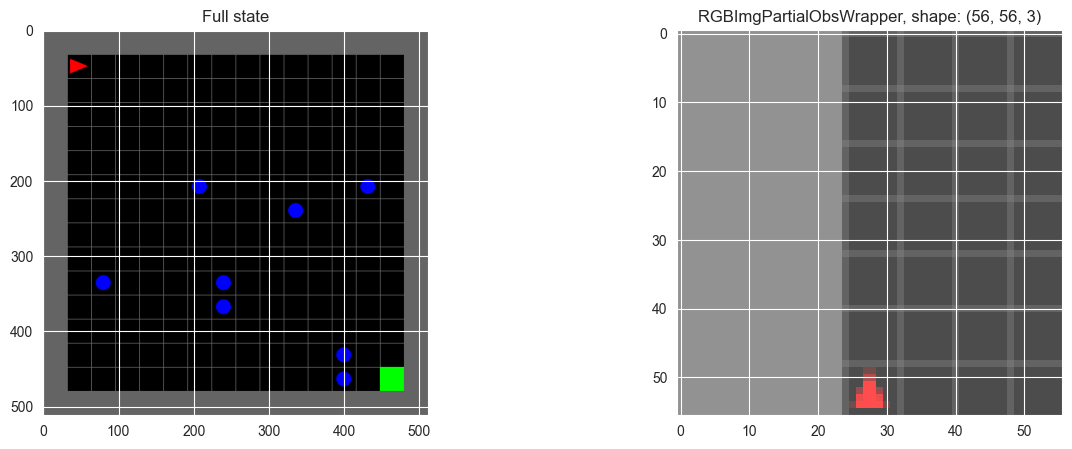

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
print(obs.shape)
axs[1].imshow(obs)
axs[1].title.set_text(f'RGBImgPartialObsWrapper, shape: {obs.shape}')
axs[0].imshow(env.render())
axs[0].title.set_text(f'Full state')
plt.show()

## Initializing the smaller environments

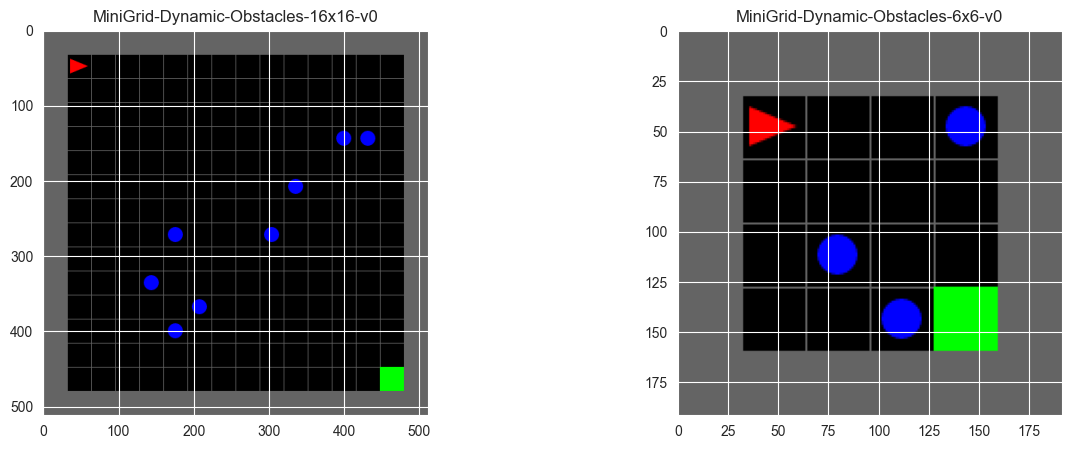

In [14]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[0].imshow(env.render())
axs[0].title.set_text(f'MiniGrid-Dynamic-Obstacles-16x16-v0')



env = gymnasium.make("MiniGrid-Dynamic-Obstacles-6x6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[1].imshow(env.render())
axs[1].title.set_text(f'MiniGrid-Dynamic-Obstacles-6x6-v0')
plt.show()

### Partial Observation Example

In [15]:
env = gymnasium.make("MiniGrid-Dynamic-Obstacles-16x16-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
video_filename = './content/vid_partial.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=10) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not done:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(obs)
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (56, 56) to (64, 64) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Our Code Lines

## 1 - A2C model Section

#### 1-A Helper function - Metric Logger

In [ ]:
#### Helper function - Metric Logger
class LiveLogger:
    """
    ▸ prints one line per episode
    ▸ keeps 100-episode rolling means
    ▸ stores history for plots + final summary
    ▸ supports free-form debug/info logs via log_info()
    """

    def __init__(self, window: int = 100, save_dir: str = "runs"):
        self.w = window
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

        # rolling windows ───────────────────────────────────────────
        self.r_R   = deque(maxlen=window)   # reward
        self.r_len = deque(maxlen=window)   # episode length
        self.r_suc = deque(maxlen=window)   # 1/0 goal reached
        self.r_col = deque(maxlen=window)   # 1/0 collision
        self.r_tmo = deque(maxlen=window)   # 1/0 timeout
        self.r_Q   = deque(maxlen=window)   # mean-max-Q or value
        self.losses = deque(maxlen=5_000)      # total loss (optional)
        self.pl_losses = deque(maxlen=5_000)   # policy
        self.vl_losses = deque(maxlen=5_000)   # value
        self.ent_losses = deque(maxlen=5_000)  # entropy (positive number you subtract)

        # full history for plots / CSV
        keys = ("episode", "step", "eps",
                "ep_len","ep_reward",
                "success","collision","timeout",
                "mean100_reward","mean100_len",
                "success_rate","collision_rate","timeout_rate",
                "Q_mean","loss",
                "policy_loss","value_loss","entropy_loss")

        self.hist = {k: [] for k in keys}

        # free-form info messages
        self.info_msgs: list[tuple[int, str]] = []

        self.t0 = time.time()

    # ───────── per-step hooks ──────────────────────────────────────
    def log_loss(self, v): self.losses.append(v)
    def log_losses(self, pl, vl, ent, tot=None):
        """Optionally log all 3 (and total)."""
        self.pl_losses.append(pl)
        self.vl_losses.append(vl)
        self.ent_losses.append(ent)
        if tot is not None:
            self.losses.append(tot)
    def log_q(self, q): self.r_Q.append(q)  # q: either mean-max-Q or mean value

    def log_info(self, msg: str, step: int | None = None):
        """
        Store and print arbitrary debug/info strings.
        """
        if step is None:
            # use last known step if available
            step = self.hist["step"][-1] if self.hist["step"] else -1
        self.info_msgs.append((step, msg))
        print(f"[info@{step}] {msg}")

    # ───────── per-episode hook ────────────────────────────────────
    def end_episode(self, ep, step, eps,
                    ep_len, ep_r,
                    success: bool,
                    collision: bool,
                    timeout: bool):
        # roll-window update
        self.r_R.append(ep_r)
        self.r_len.append(ep_len)
        self.r_suc.append(float(success))
        self.r_col.append(float(collision))
        self.r_tmo.append(float(timeout))

        # window means
        R100 = float(np.mean(self.r_R))
        L100 = float(np.mean(self.r_len))
        S100 = float(np.mean(self.r_suc)) * 100
        C100 = float(np.mean(self.r_col)) * 100
        T100 = float(np.mean(self.r_tmo)) * 100
        Q100 = float(np.mean(self.r_Q)) if self.r_Q else 0.0
        Lmean = float(np.mean(self.losses)) if self.losses else 0.0

        # live print
        dt = (time.time() - self.t0) / 60
        eps_str = f"{eps:4.2f}" if isinstance(eps, float) else " — "
        print(f"[{ep:4d}] step {step:6d}  len {ep_len:3d}  ε {eps_str}  "
              f"R {ep_r:6.2f}  R100 {R100:6.2f}  "
              f"succ {S100:5.1f}%  coll {C100:5.1f}%  t/o {T100:5.1f}%  "
              f"Q̄ {Q100:6.2f}  loss {Lmean:6.4f}  ⏱ {dt:4.1f} m")

        # store history
        pl = self.pl_losses[-1] if self.pl_losses else 0.0
        vl = self.vl_losses[-1] if self.vl_losses else 0.0
        ent= self.ent_losses[-1] if self.ent_losses else 0.0

        row = (ep, step, eps,
               ep_len, ep_r,
               int(success), int(collision), int(timeout),
               R100, L100, S100, C100, T100,
               Q100, Lmean, pl, vl, ent)
        for k, v in zip(self.hist, row):
            self.hist[k].append(v)

    def quick_plot(self):
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].plot(self.hist["episode"], self.hist["mean100_reward"])
        ax[0].set_title("mean-100 reward"); ax[0].grid(True)
        ax[1].plot(self.hist["episode"], self.hist["success_rate"])
        ax[1].set_title("mean-100 success-rate"); ax[1].grid(True)
        plt.show()

    def dump_plots(self, smooth=100):
        if len(self.hist["episode"]) == 0:
            print("Nothing logged – skipping plots.")
            return

        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        ax = axes.ravel()

        ret = self.hist["ep_reward"]
        ax[0].plot(ret, alpha=.4, lw=.7, label='raw')
        if len(ret) >= smooth:
            ma = np.convolve(ret, np.ones(smooth) / smooth, mode='valid')
            ax[0].plot(range(smooth - 1, smooth - 1 + len(ma)), ma, lw=2, label=f'{smooth}-MA')
        ax[0].set_title('Episode return'); ax[0].legend(); ax[0].grid(True)

        ax[1].plot(self.hist["ep_len"], lw=.6)
        ax[1].set_title('Episode length'); ax[1].grid(True)

        if len(self.hist["success_rate"]) >= 1:
            ax[2].plot(self.hist["success_rate"])
        ax[2].set_title('Success-rate (window)'); ax[2].grid(True)

        # if self.hist["loss"]:
        #     ax[3].plot(self.hist["loss"], lw=.6)
        # ax[3].set_title('Loss (Smooth-L1)'); ax[3].grid(True)

       # Loss components + total overlaid
        if self.hist["policy_loss"]:
            ax[3].plot(self.hist["policy_loss"], lw=.6, label='policy')
            ax[3].plot(self.hist["value_loss"],  lw=.6, label='value')
            ax[3].plot(self.hist["entropy_loss"],lw=.6, label='entropy')
        if self.hist["loss"]:
            ax[3].plot(self.hist["loss"], lw=.8, alpha=.5, linestyle='--', label='total')
        ax[3].set_title('Loss components (overlay total)'); ax[3].legend(); ax[3].grid(True)

        if self.hist["Q_mean"]:
            ax[4].plot(self.hist["Q_mean"], lw=.6)
        ax[4].set_title('mean-max-Q / V (window)'); ax[4].grid(True)

        ax[5].plot(self.hist["eps"], lw=.6)
        ax[5].set_title('ε schedule'); ax[5].grid(True)

        plt.tight_layout()
        png = os.path.join(self.save_dir, "training_dashboard.png")
        plt.savefig(png, dpi=120)
        print(f"[Logger] dashboard saved ➜ {png}")

        try:
            from IPython.display import display
            display(fig)
        except:
            pass

    def summary(self):
        suc = np.mean(self.hist["success"]) * 100
        col = np.mean(self.hist["collision"]) * 100
        tmo = np.mean(self.hist["timeout"]) * 100
        R̄ = np.mean(self.hist["ep_reward"])
        L̄ = np.mean(self.hist["ep_len"])
        print("\n==== RL run finished ====")
        print(f"Success-rate     : {suc / 100:5.3f}")
        print(f"Collision-rate   : {col / 100:5.3f}")
        print(f"Timeout-rate     : {tmo / 100:5.3f}")
        print(f"Mean reward      : {R̄:+6.3f}")
        print(f"Avg steps/ep     : {L̄:4.1f}")

        # dump misc info logs
        if self.info_msgs:
            path = os.path.join(self.save_dir, "info_log.txt")
            with open(path, "w") as f:
                for s, m in self.info_msgs:
                    f.write(f"[{s}] {m}\n")
            print(f"Info log saved ➜ {path}")

#### 1-B - Evaluation helper

In [ ]:
# ---------------------------------------------------------------------
# evaluate the policy greedily (no ε) on fresh environments
# ---------------------------------------------------------------------
@torch.no_grad()
def evaluate_greedy(
        net, *,
        env=None,
        env_size     ="6x6",
        episodes     = 3,
        device       = device,
        resize_to    =(84, 84),
        n_stack      = 1,
        video_prefix = None,
        env_type_empty = False,
):
    """
    Runs greedy (argmax) rollouts for `episodes` episodes,
    returning (mean_return, mean_length, succ_rate, coll_rate, timeout_rate).
    If no `env` is passed, makes one from env_size/resize_to/n_stack.
    """

    # 1) build env if needed
    if env is None:
        env = make_single_env(
            env_size      = tuple(map(int, env_size.split('x'))),  # e.g. "5x5" -> (5,5)
            env_obstacle  = not env_type_empty,                    # False -> Empty, True -> Dynamic-Obstacles
            seed          = np.random.randint(1_000_000),
            num_stack     = n_stack,
            max_steps     = 150,            # same as training
            resize        = resize_to,
            use_shaping   = True,           # NO reward shaping at eval
            step_penalty  = 0.0,
            dist_coef     = 0.0,
            #stay_coef     = 0.0,
            #start_penalty = 0.0
        )()

    # 2) grab your LSTM hidden size from the net
    hidden_size = net.gru.hidden_size
    num_layers = net.gru.num_layers

    returns, lengths = [], []
    succ = coll = timeout = 0

    for ep in range(episodes):
        obs, _ = env.reset(seed=np.random.randint(9999))
        done   = False
        ep_R   = 0.0
        ep_len = 0
        frames = []

        # init states: [L,B,H]  (B=1 here)
        h = torch.zeros(num_layers, 1, hidden_size, device=device)

        state = h

        # --- rollout loop ---
        while not done:
            if video_prefix:
                frames.append(obs)

            # let the net handle permute & /255
            inp = torch.as_tensor(obs, device=device).unsqueeze(0)  # [1,...]

            # forward through LSTM net
            logits, _value, state = net(inp, state)

            # greedy action
            act = int(logits.argmax(dim=-1).item())

            # step
            obs, r, term, trunc, info = env.step(act)
            done = term or trunc

            ep_R   += r
            ep_len += 1

            # whenever we finish an episode, zero out the LSTM so it doesn’t bleed
            if done:
                # zero so nothing leaks if you re-use state (not needed if loop breaks)
                h = state
                h.zero_()
                state = h

                print("r:", r, "info:", info)


        # record metrics
        returns.append(ep_R)
        lengths.append(ep_len)
        if term:
            # consider reward>0 a “success,” zero or negative a collision
            if ep_R > 0:
                succ += 1
            else:
                coll += 1
        else:
            timeout += 1

        # optional video dump
        if video_prefix:
            os.makedirs("vid", exist_ok=True)
            path = f"vid/{video_prefix}_ep{ep}.mp4"
            with imageio.get_writer(path, fps=10, macro_block_size=None) as writer:
                for frame in frames:
                    writer.append_data(frame)

    # compute averages
    N = float(episodes)
    mean_R        = float(np.mean(returns))
    mean_len      = float(np.mean(lengths))
    succ_rate     = succ    / N
    coll_rate     = coll    / N
    timeout_rate  = timeout / N

    return mean_R, mean_len, succ_rate, coll_rate, timeout_rate

#### 1-C A2C architecture

In [ ]:
class A2CNet(nn.Module):
    def __init__(self, obs_space, n_actions, hidden_size=256, num_layers=2):
        super().__init__()

        # ---- infer shape ----
        osh = obs_space.shape if hasattr(obs_space, "shape") else obs_space
        if len(osh) == 3:
            H, W, C = osh; k = 1
        elif len(osh) == 4:
            k, H, W, C = osh
        else:
            raise ValueError(f"Expected 3D/4D obs, got {osh}")
        in_ch = k * C

        # ---- CNN torso ----
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch, 32, 8, 4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2),    nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1),    nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten()
        )
        conv_out = 64*4*4
        self.fc  = nn.Linear(conv_out, hidden_size)

        # ---- GRU ----
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)

        # ---- heads ----
        self.pi    = nn.Linear(hidden_size, n_actions)
        self.value = nn.Linear(hidden_size, 1)

    def forward(self, x, h=None):
        # x: [B,k,H,W,C] or [B,H,W,C] or [B,C,H,W]
        if x.ndim == 5:               # [B,k,H,W,C]
            B,k,H,W,C = x.shape
            x = x.permute(0,4,1,2,3).reshape(B, C*k, H, W)
        elif x.ndim == 4 and x.shape[-1] in (1,3):  # [B,H,W,C]
            x = x.permute(0,3,1,2)
        # else assume [B,C,H,W]

        x = x.float().div(255)
        f = self.cnn(x)
        f = F.relu(self.fc(f)).unsqueeze(1)   # [B,1,Hid]

        L = self.gru.num_layers
        B = f.size(0)
        Hs = self.gru.hidden_size

        if h is None:
            h = torch.zeros(L, B, Hs, device=f.device)

        assert f.dim() == 3 and f.size(1) == 1, f"GRU in expects [B,1,H], got {f.shape}"
        assert h.shape == (L, B, Hs), f"h shape {h.shape} != {(L,B,Hs)}"

        out, h_new = self.gru(f, h)          # out: [B,1,H]
        z = out[:, -1]                       # [B,H]
        logits = self.pi(z)
        value  = self.value(z).squeeze(-1)   # [B]
        return logits, value, h_new


#### 1-D helper functions:
1. manhatten distance calculation helper
2. different wrappers helper

In [ ]:
def manhattan_to_goal(env):
    """Returns Manhattan distance between agent and the Goal square."""
    grid = env.unwrapped.grid
    ax, ay = env.unwrapped.agent_pos
    for x in range(env.unwrapped.width):
        for y in range(env.unwrapped.height):
            cell = grid.get(x, y)
            if cell and cell.type == "goal":
                return abs(x - ax) + abs(y - ay)
    return 0


class ExtractImageObservation(ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_shape = env.observation_space["image"].shape
        self.observation_space = Box(low=0, high=255, shape=obs_shape, dtype=np.uint8)

    def observation(self, obs):
        return obs["image"]


class ResizeImageObservation(ObservationWrapper):
    def __init__(self, env, shape=(84, 84)):
        super().__init__(env)
        self.shape = shape
        c = env.observation_space.shape[2]
        self.observation_space = Box(low=0, high=255, shape=(shape[0], shape[1], c), dtype=np.uint8)

    def observation(self, obs):
        return cv2.resize(obs, self.shape, interpolation=cv2.INTER_AREA)


class GrayScaleObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_shape = self.observation_space.shape[:2]
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=obs_shape, dtype=np.uint8
        )

    def observation(self, obs):
        return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)


def make_vec_env(
        num_envs: int = 8,
        seed: int = 0,
        num_stack: int = 4,
        env_size: tuple[int, int] = (5, 5),
        env_obstacle: bool = True,
        max_steps: int = 150,
        resize: tuple[int, int] = (84, 84),
):
    """
    Creates `num_envs` parallel MiniGrid envs of size `env_size` with or without obstacles.
    """

    def make_single_env_fn(rank):
        return make_single_env(
            seed=seed + rank,
            num_stack=num_stack,
            env_size=env_size,
            env_obstacle=env_obstacle,
            max_steps=max_steps,
            resize=resize,
        )

    return AsyncVectorEnv([make_single_env_fn(i) for i in range(num_envs)])


def make_single_env(
        env_size: tuple[int, int] = (5, 5),
        env_obstacle: bool = True,
        seed: int = 0,
        num_stack: int = 4,
        max_steps: int = 150,
        resize: tuple[int, int] = (84, 84),
        use_shaping=True,
        **shape_kw
):
    """
    Builds one MiniGrid env:
      - size:          (W,H)
      - dynamic obs?:  env_obstacle
      - frame-stack:   num_stack
      - time limit:    max_steps
      - resize to:     `resize`
    """

    def thunk():
        # pick the right env id based on size & obstacle flag:
        size_str = f"{env_size[0]}x{env_size[1]}"
        prefix = "Dynamic-Obstacles" if env_obstacle else "Empty"
        env_id = f"MiniGrid-{prefix}-{size_str}-v0"

        env = gym.make(env_id, render_mode="rgb_array", highlight=False)

        # ---- wrappers ----
        env = RGBImgObsWrapper(env)  # get full-grid RGB
        env = ImgObsWrapper(env)  # obs = Box(H,W,3)
        env = ResizeObservation(env, shape=resize)  # → (84,84,3)
        env = FrameStackObservation(env, num_stack)  # → (num_stack,84,84,3)

        # >>> add shaping wrapper here <<<
        if use_shaping:
            env = PotentialRewardWrapper(env, **shape_kw)

        env = RecordEpisodeStatistics(env)  # track return / length
        env = TimeLimit(env, max_episode_steps=max_steps)  # cap episode length

        # seed both action & observation spaces
        env.action_space.seed(seed)
        env.observation_space.seed(seed)

        return env

    return thunk

#### 1-E Training helpers
1. reward shaping
2. potenshial shaping
3. extract info helpers
4. episode recorder helper

In [ ]:
class LinearScheduler:
    def __init__(self, start, end, duration):
        self.start, self.end, self.duration = start, end, duration
        self.t = 0
    def step(self, dt):
        self.t += dt
        a = min(1.0, self.t / self.duration)
        return (1-a)*self.start + a*self.end


def categorical_kl(old_logits, new_logits):
    """KL(old || new) for categorical distributions, batched on last dim."""
    old_logp = F.log_softmax(old_logits, dim=-1)
    new_logp = F.log_softmax(new_logits, dim=-1)
    old_p    = old_logp.exp()
    return (old_p * (old_logp - new_logp)).sum(-1)  # [batch]


class PotentialRewardWrapper(gym.Wrapper):
    """
    Implements policy‑invariant potential‑based shaping plus a simple revisit penalty.
    """
    def __init__(
        self,
        env,
        gamma: float = 0.99,
        step_penalty: float = -0.01,
        dist_coef: float = 0.1,
        revisit_penalty: float = -0.01,
    ):
        super().__init__(env)
        self.gamma          = gamma
        self.step_penalty   = step_penalty
        self.dist_coef      = dist_coef
        self.revisit_penalty = revisit_penalty

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # find goal once per episode
        self._goal_pos = self._find_goal_pos()
        # compute initial potential
        self._prev_phi  = self._phi()
        # track visited cells to penalize revisits
        self._visited   = { tuple(self.unwrapped.agent_pos) }
        return obs, info

    def step(self, action):
        obs, r_base, terminated, truncated, info = self.env.step(action)
        cur_pos = tuple(self.unwrapped.agent_pos)

        # --- potential‐based shaping term ---
        phi_next = self._phi()
        shaping  = self.dist_coef * (self.gamma * phi_next - self._prev_phi)
        self._prev_phi = phi_next

        # --- revisit penalty ---
        if cur_pos in self._visited:
            revisit = self.revisit_penalty
        else:
            self._visited.add(cur_pos)
            revisit = 0.0

        # --- combine ---
        r_shaped = r_base + self.step_penalty + shaping + revisit

        return obs, r_shaped, terminated, truncated, info

    def _phi(self) -> float:
        """Potential = –Manhattan distance to goal."""
        agent = np.array(self.unwrapped.agent_pos)
        goal  = np.array(self._goal_pos)
        return -float(np.abs(agent - goal).sum())

    def _find_goal_pos(self):
        grid = self.unwrapped.grid
        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)
                if isinstance(obj, Goal):
                    return (x, y)
        return (0, 0)


# helper for safe info access
def _g(info, key, default):
    return info.get(key, default) if isinstance(info, dict) else default


def extract_info_arrays(infos, terminated, truncated, n_envs):
    """
    Return per-env arrays:
        raw_r, succ, coll, tout, d_start, d_end, ep_steps_info
    Falls back gracefully if keys are missing in info.
    """
    def _scalar(x, default):
        if x is None: return default
        try:
            return float(np.asarray(x).reshape(-1)[0])
        except Exception:
            return default

    def _bool(x, default):
        if x is None: return default
        if isinstance(x, (bool, np.bool_)): return bool(x)
        try:
            return bool(np.asarray(x).reshape(-1)[0])
        except Exception:
            return default

    raw_r   = np.zeros(n_envs, dtype=np.float32)
    succ    = np.zeros(n_envs, dtype=bool)
    coll    = np.zeros(n_envs, dtype=bool)
    tout    = np.zeros(n_envs, dtype=bool)
    d_start = np.full(n_envs, np.nan, dtype=np.float32)
    d_end   = np.full(n_envs, np.nan, dtype=np.float32)
    ep_steps_info = np.full(n_envs, -1, dtype=np.int32)

    # Helper to fill one index
    def fill_i(i, inf):
        # default fallbacks
        ttrunc = bool(truncated[i])
        tterm  = bool(terminated[i])

        tl_trunc = inf.get("TimeLimit.truncated", False) if isinstance(inf, dict) else False
        timeout_flag = ttrunc or tl_trunc

        raw_r[i] = _scalar(inf.get("raw_reward", 0.0) if isinstance(inf, dict) else None, 0.0)
        tout[i]  = _bool(inf.get("timeout", timeout_flag) if isinstance(inf, dict) else None, timeout_flag)

        # trust explicit flags, otherwise default False
        succ[i] = _bool(inf.get("success",   False) if isinstance(inf, dict) else None, False)
        coll[i] = _bool(inf.get("collision", False) if isinstance(inf, dict) else None, False)

        d_start[i] = _scalar(inf.get("dist_start", np.nan) if isinstance(inf, dict) else None, np.nan)
        d_end[i]   = _scalar(inf.get("dist_end",   np.nan) if isinstance(inf, dict) else None, np.nan)
        ep_steps_info[i] = int(_scalar(inf.get("ep_steps", -1) if isinstance(inf, dict) else None, -1))

    # ----- main fill logic -----
    if isinstance(infos, dict):
        # vectorized dict-of-arrays case
        rr = infos.get("raw_reward")
        sc = infos.get("success")
        co = infos.get("collision")
        to = infos.get("timeout")
        ds = infos.get("dist_start")
        de = infos.get("dist_end")
        es = infos.get("ep_steps")
        tl = infos.get("TimeLimit.truncated")

        for i in range(n_envs):
            inf = {
                "raw_reward":   rr[i] if hasattr(rr, "__len__") else rr,
                "success":      sc[i] if hasattr(sc, "__len__") else sc,
                "collision":    co[i] if hasattr(co, "__len__") else co,
                "timeout":      to[i] if hasattr(to, "__len__") else to,
                "dist_start":   ds[i] if hasattr(ds, "__len__") else ds,
                "dist_end":     de[i] if hasattr(de, "__len__") else de,
                "ep_steps":     es[i] if hasattr(es, "__len__") else es,
                "TimeLimit.truncated": tl[i] if hasattr(tl, "__len__") else tl
            }
            fill_i(i, inf)
        return raw_r, succ, coll, tout, d_start, d_end, ep_steps_info

    if isinstance(infos, (list, tuple)):
        L = min(len(infos), n_envs)
        for i in range(L):
            inf = infos[i] if isinstance(infos[i], dict) else {}
            fill_i(i, inf)
        for i in range(L, n_envs):
            # no info: fallback to truncated only
            tout[i] = bool(truncated[i])
        return raw_r, succ, coll, tout, d_start, d_end, ep_steps_info

    # Fallback: no infos at all
    for i in range(n_envs):
        tout[i] = bool(truncated[i])
    return raw_r, succ, coll, tout, d_start, d_end, ep_steps_info


# ─── create a very small helper ──────────────────────────────
class EpisodeRecorder:
    """Collect frames from env‑index 0 and dump mp4 when the episode ends."""
    def __init__(self, every=20_000, out_dir="vid", fps=8):
        self.every   = every          # record every N environment frames
        self.out_dir = out_dir
        self.fps     = fps
        self.next_at = every          # schedule
        self.frames  = None
        os.makedirs(out_dir, exist_ok=True)

    def maybe_start(self, step_count, first_frame):
        if self.frames is None and step_count >= self.next_at:
            self.frames  = [first_frame]
            self.next_at += self.every         # schedule next video

    def step(self, frame, done, step_count):
        if self.frames is not None:
            self.frames.append(frame)
            if done:                           # episode finished → dump
                path = f"{self.out_dir}/train_{step_count//1000:05d}.mp4"
                with imageio.get_writer(path, fps=self.fps,
                                         macro_block_size=None) as w:
                    for fr in self.frames:
                        w.append_data(fr)
                print(f"[video] saved {path}")
                self.frames = None


#### 1-F Training A2C function

In [ ]:
def train_a2c_vectorized(
    envs,
    model,
    optimizer,
    n_steps=32,
    gamma=0.99,
    lam=0.95,
    value_coef=0.5,
    entropy_start=0.05,
    entropy_end=0.005,
    entropy_floor=0.03,
    eps_start=0.30,
    eps_end=0.05,
    step_penalty=-0.0005,
    max_steps=100_000,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    eval_every=5_000,
    logger=None,
    env_size="5x5",
    resize_to=(84, 84),
    n_stack=4,
    hidden_size=256,
    obstacles=True,
    # --- New knobs ---
    kl_thresh=0.05,
    kl_chunk=4096,
    clip_range_v=0.2,
    policy_coef = 100

):
    """
    Vectorized A2C with GRU memory, GAE(λ), advantage normalization,
    PPO-style value clipping, and KL rollback.
    """

    warmup_kl = 75_000  # first 75k env steps: no rollback
    rec = EpisodeRecorder(every=7_000)   # one clip every 50 k env‑frames


    n_envs = envs.num_envs
    obs, _ = envs.reset()

    step_count = 0
    episode    = 0
    ep_lens    = np.zeros(n_envs, dtype=np.int32)
    ep_returns = np.zeros(n_envs, dtype=np.float32)

    # --- GRU hidden state ---
    num_layers = model.gru.num_layers
    state = torch.zeros(num_layers, n_envs, hidden_size, device=device)

    # entropy and epsilon schedule
    ent_sched = LinearScheduler(entropy_start, entropy_end, duration=max_steps)
    eps_sched = LinearScheduler(eps_start,     eps_end,     duration=max_steps)

    last_eval_step = 0
    log_every_updates = 1   # or 10 to reduce spam
    update_idx = 0          # put this before the main while-loop (outside)


    while step_count < max_steps:

        # Rollout storage
        rewards, dones = [], []
        log_probs, values, entropies = [], [], []

        # For KL check
        old_logits_list = []
        obs_list        = []
        state_in_list   = []

        # ------------- COLLECT ROLLOUT -------------
        for _ in range(n_steps):
            obs_tensor = torch.as_tensor(obs, device=device)

            # Save inputs for KL recomputation
            obs_list.append(torch.as_tensor(obs))             # CPU
            state_in_list.append(state.clone().detach())

            logits, value, state = model(obs_tensor, state)
            old_logits_list.append(logits.detach())

            dist = torch.distributions.Categorical(logits=logits)

            # --- ε-greedy ---
            eps = eps_sched.step(n_envs)                 # advance by batch size

            rand_mask = (torch.rand(logits.size(0), device=logits.device) < eps)

            greedy_action = dist.sample()                # policy sample
            random_action = torch.randint(logits.size(-1), (logits.size(0),), device=logits.device)

            action = torch.where(rand_mask, random_action, greedy_action)

            # We need log_prob/entropy of the *policy*, not the ε-mixed one (A2C standard)
            log_prob = dist.log_prob(action)
            entropy  = dist.entropy()
            next_obs, r_env, terminated, truncated, infos = envs.step(action.cpu().numpy())
            done_np = np.logical_or(terminated, truncated)

            ##########################################
            #  grab the rendered RGBArray for *env index 0* only
            frame0 = envs.render()[0]          # ← ndarray H×W×3 uint8
            if isinstance(frame0, dict):                 # Gymnasium
                frame0 = frame0["pixels"]

            # start recorder if schedule reached
            rec.maybe_start(step_count, frame0)

            # let recorder collect frame until episode‑0 ends
            rec.step(frame0, done_np[0], step_count)

            ######################################

            step_count += n_envs

            # shaped reward is r_env (already shaped by wrapper)
            reward_t = torch.as_tensor(r_env, device=device, dtype=torch.float32)

            done_b   = torch.as_tensor(done_np, device=device, dtype=torch.bool)

            # ---- extract raw reward & flags from info ----
            raw_r, succ, coll, tout, d_start, d_end, ep_steps_info = extract_info_arrays(
                infos, terminated, truncated, n_envs
            )


            # mask GRU state
            not_done_f = (~done_b).float().view(1, -1, 1)
            state = state * not_done_f

            # store
            rewards.append(reward_t)
            dones.append(done_b)
            log_probs.append(log_prob)
            values.append(value)
            entropies.append(entropy)

            # bookkeeping
            obs = next_obs
            ep_lens    += 1
            ep_returns += r_env
            step_count += n_envs     #  n_envs         # <<< increment global frame counter

            if logger:
                for i in range(n_envs):
                    if done_np[i]:
                        # ---- debug every 100 eps ----
                        if episode % 100 == 0:
                            ds = d_start[i]
                            de = d_end[i]
                            es = ep_steps_info[i]
                            print(f"[ep {episode}] dist {ds:.0f}->{de:.0f}, steps {es}, "
                                  f"S={bool(succ[i])}, C={bool(coll[i])}, T={bool(tout[i])}")

                        logger.end_episode(
                            episode,
                            int(step_count),
                            eps=None,
                            ep_len=int(ep_lens[i]),
                            ep_r=ep_returns[i],
                            success=bool(succ[i]),
                            collision=bool(coll[i]),
                            timeout=bool(tout[i])
                        )
                        episode        += 1
                        ep_lens[i]      = 0
                        ep_returns[i]   = 0.0
        # ---------- BOOTSTRAP VALUE FOR GAE ----------
        with torch.no_grad():
            obs_tensor = torch.as_tensor(obs, device=device)
            _, next_value, state = model(obs_tensor, state)

            last_done = dones[-1].float()
            next_value = next_value * (1.0 - last_done)

            mask = (1.0 - last_done).view(1, -1, 1)
            state = state * mask

        # ---------- GAE(λ) (fixed shapes) ----------
        rews    = torch.stack(rewards, dim=0)                   # [T,B]
        dones_t = torch.stack(dones,   dim=0).float()            # [T,B]
        vals    = torch.stack(values,  dim=0).squeeze(-1)        # [T,B]

        # Bootstrap next values: shift vals and use next_value for last step
        next_values_t = torch.zeros_like(vals)
        next_values_t[:-1] = vals[1:]
        next_values_t[-1]  = next_value.squeeze(-1)              # [B]

        advantages = torch.zeros_like(rews)
        lastgaelam = torch.zeros(n_envs, device=device)
        for t in reversed(range(rews.size(0))):
            nonterminal = 1.0 - dones_t[t]
            delta = rews[t] + gamma * next_values_t[t] * nonterminal - vals[t]
            lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
            advantages[t] = lastgaelam

        returns_t = advantages + vals                            # [T,B]

        # Flatten once
        adv_flat      = advantages.view(-1)
        ret_flat      = returns_t.view(-1)
        vals_flat     = vals.view(-1)
        vals_old_flat = vals_flat.detach()

        # ---------- LOSSES ----------
        logp_flat = torch.cat(log_probs, dim=0)

        raw_adv_flat = advantages.view(-1)
        raw_adv_std  = raw_adv_flat.std().item()

        # normalize
        adv_flat = (raw_adv_flat - raw_adv_flat.mean()) / (raw_adv_flat.std() + 1e-8)


        # policy & entropy
        policy_loss  = -(logp_flat * adv_flat.detach()).mean()
        entropy_loss = torch.cat(entropies, dim=0).mean()

        # PPO-style value clipping
        v_pred         = vals_flat
        v_pred_clipped = vals_old_flat + (v_pred - vals_old_flat).clamp(-clip_range_v, clip_range_v)
        value_loss_unclipped = F.mse_loss(v_pred,         ret_flat, reduction='none')
        value_loss_clipped   = F.mse_loss(v_pred_clipped, ret_flat, reduction='none')
        value_loss = torch.max(value_loss_unclipped, value_loss_clipped).mean()


        frames_this_update = n_steps * n_envs

        entropy_coef = ent_sched.step(frames_this_update)
        entropy_coef = max(entropy_coef, entropy_floor)
        loss = policy_coef * policy_loss + value_coef * value_loss - entropy_coef * entropy_loss
        print(f"pl={policy_coef * policy_loss.item():.6f}  vl={value_coef * value_loss.item():.6f}  ent={entropy_coef * entropy_loss.item():.6f}")
        # ---- debug log of loss components & stats ----
        if logger:
            # store components for plots
            logger.log_losses(policy_loss.item(),
                              value_loss.item(),
                              entropy_loss.item(),
                              loss.item())

        # --------- BACKUP PARAMS FOR ROLLBACK -----------
        backup = {k: v.clone() for k, v in model.state_dict().items()}

        # --------- OPTIMIZE -----------
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()


        # --------- KL CHECK -----------
        with torch.no_grad():
            new_logits_flat = []
            old_logits_flat = []

            for t in range(n_steps):
                obs_t   = obs_list[t].to(device)
                state_t = state_in_list[t]
                logits_new, _, _ = model(obs_t, state_t)
                new_logits_flat.append(logits_new)
                old_logits_flat.append(old_logits_list[t])

            new_logits_flat = torch.cat(new_logits_flat, dim=0)
            old_logits_flat = torch.cat(old_logits_flat, dim=0)

            # chunk for memory safety
            kl_vals = []
            for i in range(0, new_logits_flat.size(0), kl_chunk):
                j = i + kl_chunk
                kl_chunk_val = categorical_kl(old_logits_flat[i:j], new_logits_flat[i:j])
                kl_vals.append(kl_chunk_val)
            kl_mean = torch.cat(kl_vals).mean().item()


        update_idx += 1

        if logger:
            logger.log_loss(loss.item())
            logger.log_losses(policy_coef * policy_loss.item(), value_coef* value_loss.item(), entropy_coef* entropy_loss.item(), loss.item())
            logger.log_q(vals_flat.mean().item())



        if hasattr(logger, "log_info"):
            logger.log_info(f"KL={kl_mean:.4f}")

        # rollback only after warmup
        if step_count >= warmup_kl and kl_mean > kl_thresh:
            model.load_state_dict(backup)
            optimizer.zero_grad()
            for pg in optimizer.param_groups:
                pg["lr"] *= 0.5
            if logger and hasattr(logger, "log_info"):
                logger.log_info(f"KL {kl_mean:.4f} > {kl_thresh}, rollback & LR halved")


        # ---------- EVAL ----------
        if eval_every and (step_count - last_eval_step) >= eval_every:
            last_eval_step = step_count

            R̄, L̄, S̄, coll_rate, timeout_rate = evaluate_greedy(
                net=model,
                episodes=3,
                device=device,
                resize_to=resize_to,
                n_stack=n_stack,
                video_prefix= None,
                env_size=env_size,
                env_type_empty=not obstacles
            )
            print(f"🔎 eval  R̄={R̄:.2f}  len̄={L̄:.0f}  succ̄={S̄*100:.1f}%")

    # ---------- FINALIZE ----------
    if logger:
        logger.dump_plots()
        logger.summary()


#### 1-G Training applying and starting to train

In [ ]:
num_envs = 16
n_stack  = 4
hidden_size = 256

# 1) dummy env to infer obs_shape and n_actions
dummy = make_vec_env(
    num_envs   = 1,
    seed       = 0,
    num_stack  = n_stack,
    env_size   = (5,5),
    env_obstacle=False
)
obs_shape = dummy.single_observation_space.shape   # e.g. (4,84,84,3)
n_actions = dummy.single_action_space.n
dummy.close()

# 1) build model & optimizer once
model     = A2CNet(obs_shape, hidden_size=hidden_size, n_actions=n_actions).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-5)
logger    = LiveLogger(window=100, save_dir="runs")

# 2) define your curriculum: (env_size, obstacles, train_steps)
curriculum = [
    ("5x5", False, 300_000),   # phase 1: small empty
    ("5x5", True,  300_000),   # phase 2: same size but add obstacles
    ("8x8", False,  800_000),   # phase 3: bigger
    ("8x8", True,  800_000),   # phase 3: bigger
    ("16x16", True, 2_000_000),  # phase 4: biggest
]

for (env_size, obstacles, max_steps) in curriculum:
    print(f"\n--- Curriculum phase: {env_size}, obstacles={obstacles}, steps={max_steps} ---")

    # 3) recreate your VecEnv with the new settings
    #    (assumes make_vec_env takes an `env_size` and `obstacles` kwarg)
    envs = make_vec_env(
        num_envs    = num_envs,
        seed        = 44,
        num_stack   = n_stack,
        env_size    = tuple(map(int, env_size.split('x'))),
        env_obstacle= obstacles   # ← here
    )


    # 4) train for exactly `max_steps` frames/updates in this phase
    train_a2c_vectorized(
        envs, model, optimizer,
        # rollout & GAE
        n_steps=16,
        gamma=0.99,
        lam=0.95,
        hidden_size=hidden_size,
        # loss weights
        policy_coef = 15,
        value_coef=0.16,
        entropy_start=0.05,
        entropy_end=0.000,
        entropy_floor=0.00,
        eps_start=0.000,
        eps_end=0.0000,
        step_penalty=-0.002,
        # budget & logging
        max_steps=max_steps,
        eval_every=10_000,
        logger=logger,
        # eval config
        env_size=env_size,
        resize_to=(84, 84),
        n_stack=n_stack,
        obstacles=obstacles,
    )

    envs.close()

# after all phases
save_path = "runs/a2c_curriculum_checkpoint1.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    # you can also save your curriculum index, step count, etc.
}, save_path)
print(f"[+] checkpoint saved to {save_path}")
print("🏁 Done with all curriculum phases!")


model.eval()

#### 1-H - helper function to display mp4 in notebook and debug results

In [ ]:
# --------- helper to display mp4 in notebook ----------
def embed_mp4(filename):
    video = open(filename, 'rb').read()
    b64 = base64.b64encode(video).decode()
    html = f"""
    <video width="640" height="480" controls>
      <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """
    return IPython.display.HTML(html)

env_size="5x5"
obstacles = False

env_vid = make_vec_env(
    num_envs   = 16,
    seed       = 0,
    num_stack  = 4,
    env_size   = (5,5),
    env_obstacle=False
)
obs_shape = env_vid.single_observation_space.shape   # e.g. (4,84,84,3)
n_actions = env_vid.single_action_space.n
# how many envs did we actually create?
B = env_vid.num_envs

# ---------- load model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[+] observation shape: {obs_shape}, actions: {n_actions}")

model.eval()

# ---------- run one greedy episode & record ----------
video_filename = "./content/vid122.mp4"
num_layers = model.gru.num_layers
hidden_size = model.gru.hidden_size
state = torch.zeros(num_layers, B, hidden_size, device=device)
print(state.shape)
obs, _ = env_vid.reset()                 # obs: (1, 4, 84, 84, 3)
done = truncated = False
total_reward = steps = 0

def first_frame():                       # helper for rendering
    f = env_vid.render()
    if isinstance(f, (list, tuple)):
        f = f[0]                         # pick worker‑0
    if isinstance(f, dict):
        f = f["pixels"]
    return f

with imageio.get_writer(video_filename, fps=4) as video:
    video.append_data(first_frame())

    with torch.no_grad():
        while not (done or truncated):

            obs_t = torch.as_tensor(obs, device=device)      # (1,4,84,84,3)

            # infer actions for the whole batch
            logits, value, state = model(obs_t, state)        # logits shape (B, n_actions)
            actions = logits.argmax(-1).cpu().numpy()         # one greedy action per env

            obs, reward, done, truncated, info = env_vid.step(actions)
            reward, done, truncated = reward[0], done[0], truncated[0]


            total_reward += reward
            steps += 1
            video.append_data(first_frame())

            if done or truncated:
                state.zero_()

print(f"Episode finished. Return={total_reward:.2f}, steps={steps}")
env_vid.close()

# ---------- show it ----------
embed_mp4(video_filename)

## 2 - DQN model Section

## Stage A - Environment and Observation Pipline
1. Create a helper that instantiates any Dynamic-Obstacles map with the exact observation format our agents will consume.
2. Verify shapes, terminated / truncated flags, and optional video capture.

#### 2 (A-1) Utility wrappers:

In [16]:
class SimpleResizeObs(gym.ObservationWrapper):
    """Resize ndarray observation (H,W,3) to target shape with nearest-neighbour.
    	•	Bigger receptive field – A 56×56 crop collapses after two 3×3 conv layers; 84×84 lets a small CNN capture spatial relations.
	    •	Video compatibility – 64, 80, 96, … are multiples of 16, so MP4 encoders don’t warn.
	    •	Consistent input – Every experiment, seed, and grid size produces the same tensor size for the network."""
    def __init__(self, env, shape=(84, 84)):
        super().__init__(env)
        self.shape = shape                # (H, W)
        h, w = shape
        # Detect whether we're dealing with a Dict or a Box
        if isinstance(env.observation_space, gym.spaces.Dict):
            c = env.observation_space["image"].shape[-1]
        else:                                    # already a Box
            c = env.observation_space.shape[-1]

        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(h, w, c), dtype=np.uint8
        )

    def observation(self, obs: np.ndarray) -> np.ndarray:
        # Extract the RGB image
        if isinstance(obs, dict):
            img = obs["image"]
        else:
            img = obs                      # already a plain array

        # Resize (using cv2, PIL, or torch-vision – pick one)
        img = cv2.resize(img, self.shape, interpolation=cv2.INTER_AREA)
        return img


class SimpleFrameStack(gym.Wrapper):
    """Stack last *k* images along axis 0  →  (k,H,W,3) uint8.
    	•	Partial observability – the agent cannot see behind itself; stacked frames give a short-term memory of what just left view.
	    •	Motion cues – obstacle velocity (and the agent’s own motion) becomes visible via frame differences, letting a plain CNN learn without an LSTM.
	    •	Keeps network simple – avoids writing a custom recurrent head until we benchmark the basic CNN."""
    def __init__(self, env, k: int = 4):
        super().__init__(env)
        self.k        = k
        self.frames   = deque([], maxlen=k)
        h, w, c       = env.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low = 0, high = 255, shape=(k, h, w, c), dtype=np.uint8
        )

    # ------------------------------------------------------------------ API
    def reset(self, **kw):
        obs, info = self.env.reset(**kw)
        self.frames.extend([obs] * self.k)          # fill deque
        return self._get_obs(), info

    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), r, term, trunc, info
    # ----------------------------------------------------------------------
    def _get_obs(self):
        return np.stack(self.frames, axis=0)

#### 2(A-2) Environment Factory:

In [17]:
# from wrappers          import SimpleResizeObs, SimpleFrameStack

def make_env(size: str            = "16x16",
             seed: int            = 0,
             resize_to: Optional[Tuple[int, int]] = (84, 84),
             n_stack: int         = 4):
    """
    size      : '5x5', '6x6', '8x8', or '16x16'
    resize_to : None  → keep raw 56×56
                (H,W) → upscale with nearest‐neighbour
    n_stack   : 0 or 1 → no frame stack (DRQN)
                k>1     → stack last k frames (DQN)
    """
    env_id = f"MiniGrid-Dynamic-Obstacles-{size}-v0"
    env = gym.make(env_id, render_mode="rgb_array", highlight=False)

    # partial RGB crop → plain ndarray (H,W,3)
    env = RGBImgPartialObsWrapper(env)   # crop of what agent sees
    env = ImgObsWrapper(env)             # dict→ndarray (56,56,3)

    # optional up‐/down‐scaling
    if resize_to is not None:
        env = SimpleResizeObs(env, resize_to)      # e.g. (84,84,3)

    # only stack when you really want more than one frame
    if n_stack > 1:
        env = SimpleFrameStack(env, k=n_stack)     # e.g. (4,84,84,3)

    env.reset(seed=seed)
    return env

#### Smoke tests:
testing of our functions

In [18]:
def test_shapes():
    env = make_env("6x6", seed=42)
    obs, _ = env.reset()
    print("Obs shape :", obs.shape)           # expect (4,84,84,3)
    assert obs.shape  == (4, 84, 84, 3)
    assert obs.dtype  == np.uint8
    print("✓ shape & dtype OK")

def test_flags():
    env = make_env("5x5", seed=0, resize_to=None, n_stack=0)
    obs, _ = env.reset()
    terminated = truncated = False
    while not (terminated or truncated):
        obs, _, terminated, truncated, _ = env.step(env.action_space.sample())
    print(f"✓ episode ended via {'terminated' if terminated else 'truncated'}")

def test_video():
    env = make_env("6x6", seed=1, resize_to=None, n_stack=0)
    vid = "quick.mp4"
    with imageio.get_writer(vid, fps=10, macro_block_size=None) as w:
        obs, _ = env.reset()
        for _ in range(20):
            w.append_data(obs)                               # note: obs is ndarray
            obs, _, term, trunc, _ = env.step(env.action_space.sample())
            if term or trunc:
                break
    print("✓ video saved to", os.path.abspath(vid))

# Run tests
test_shapes()
test_flags()
test_video()

Obs shape : (4, 84, 84, 3)
✓ shape & dtype OK
✓ episode ended via terminated
✓ video saved to /Users/igornazarenko/PycharmProjects/FinalRL/quick.mp4


#### 2(A-3) Helper function - Metric Logger

In [19]:
import csv, time, os
from collections import deque
import numpy as np
import imageio

from collections import deque
import time, numpy as np, matplotlib.pyplot as plt

class LiveLogger:
    """
    ▸ prints one line per episode
    ▸ keeps 100-episode rolling means
    ▸ stores history for plots + final summary
    """

    def __init__(self, window: int = 100, save_dir: str = "runs"):
        self.w = window
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

        # -------------- rolling windows (episode-level) --------------
        self.r_R    = deque(maxlen=window)   # raw reward
        self.r_Rsh  = deque(maxlen=window)   # shaped reward
        self.r_len  = deque(maxlen=window)
        self.r_suc  = deque(maxlen=window)
        self.r_col  = deque(maxlen=window)
        self.r_tmo  = deque(maxlen=window)
        self.r_Q    = deque(maxlen=window)   # DRQN only

        # -------------- step/update-level series ---------------------
        self.losses      = deque(maxlen=5_000)
        self.entropies   = deque(maxlen=5_000)  # A2C only
        self.kls         = deque(maxlen=5_000)  # A2C only
        self.grad_norms  = deque(maxlen=5_000)  # A2C only
        self.adv_mu      = deque(maxlen=5_000)  # A2C only
        self.adv_sigma   = deque(maxlen=5_000)  # A2C only
        self.dist_delta  = deque(maxlen=window) # Δ distance/ep (either alg.)


        # step-level collections
        self.q_samples = []                 # Q-max stream
        self.pri_mean  = []                 # replay priority μ
        self.isw_mean  = []                 # IS-weight μ
        self.isw_std   = []                 # IS-weight σ

        # -------------- full history (episode granularity) -----------
        keys = (
            "episode", "step", "eps",
            "ep_len", "ep_reward",              # raw
            "success", "collision", "timeout",
            "mean100_reward", "mean100_len",
            "success_rate", "collision_rate", "timeout_rate",
            "Q_mean",           # DRQN
            "loss", "entropy",  # loss for both, entropy for A2C
            "kl", "grad_norm", "Δdist", "adv_mu", "adv_std",
            "ep_reward_shaped"  # shaped
        )
        self.hist = {k: [] for k in keys}
        self.t0 = time.time()

    # ────────────────────────── per-step hooks ─────────────────────
    def log_loss(self, v):          self.losses.append(v)
    def log_entropy(self, v):       self.entropies.append(v)
    def log_q(self, q):
        self.r_Q.append(q);  self.q_samples.append(q)
    def log_priority(self, pri_m, isw_m, isw_s):
        self.pri_mean.append(pri_m); self.isw_mean.append(isw_m); self.isw_std.append(isw_s)
    def log_dist_delta(self, d):    self.dist_delta.append(d)

    def log_update_stats(self, pl, vl, kl, gnorm, adv_m, adv_s):
        """Call once per *gradient update* (A2C)."""
        self.kls.append(kl); self.grad_norms.append(gnorm)
        self.adv_mu.append(adv_m); self.adv_sigma.append(adv_s)

    # ────────────────────────── utilities ──────────────────────────
    def success_rate(self) -> float:
        """Rolling mean success-rate (last 100 episodes)."""
        return float(np.mean(self.r_suc)) if self.r_suc else 0.0

    # ───────────────────────── episode-end hook ────────────────────
    def end_episode(self, ep, step, eps,
                    ep_len, ep_r_raw, ep_r_shaped,
                    success: bool, collision: bool, timeout: bool):

        # update rolling windows
        self.r_R.append(ep_r_raw);      self.r_Rsh.append(ep_r_shaped)
        self.r_len.append(ep_len)
        self.r_suc.append(float(success)); self.r_col.append(float(collision))
        self.r_tmo.append(float(timeout))

        # compute window means
        R100 = float(np.mean(self.r_R))
        L100 = float(np.mean(self.r_len))
        S100 = float(np.mean(self.r_suc))*100
        C100 = float(np.mean(self.r_col))*100
        T100 = float(np.mean(self.r_tmo))*100
        Q100 = float(np.mean(self.r_Q)) if self.r_Q else 0.0
        Lmean= float(np.mean(self.losses))     if self.losses    else 0.0
        Emean= float(np.mean(self.entropies))  if self.entropies else 0.0
        KLm  = float(np.mean(self.kls))        if self.kls       else 0.0
        GNm  = float(np.mean(self.grad_norms)) if self.grad_norms else 0.0
        D100 = float(np.mean(self.dist_delta)) if self.dist_delta else 0.0

        # live print
        dt=(time.time()-self.t0)/60
        print(f"[{ep:4d}] step {step:6d}  ε {eps:4.2f} "
              f"R {ep_r_raw:6.2f}  R100 {R100:6.2f}  "
              f"succ {S100:5.1f}%  coll {C100:5.1f}%  t/o {T100:5.1f}%  "
              f"Q̄ {Q100:6.2f}  loss {Lmean:6.4f}  H {Emean:5.3f} "
              f"KL {KLm:5.3f}  ∥g∥ {GNm:5.2f}  Δd {D100:+5.2f}  ⏱ {dt:4.1f} m")

        # save row
        row = (
            ep, step, eps,
            ep_len, ep_r_raw,
            int(success), int(collision), int(timeout),
            R100, L100, S100, C100, T100,
            Q100, Lmean, Emean,
            KLm, GNm, D100,
            float(np.mean(self.adv_mu)) if self.adv_mu else 0.0,
            float(np.mean(self.adv_sigma)) if self.adv_sigma else 0.0,
            ep_r_shaped
        )
        for k, v in zip(self.hist, row):
            self.hist[k].append(v)



    # ───────────────────── quick 2-panel peek ─────────────────────
    def quick_plot(self):
        if not self.hist["episode"]:
            print("Nothing to plot yet."); return
        fig,ax=plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(self.hist["episode"],self.hist["mean100_reward"]); ax[0].set_title("mean-100 reward"); ax[0].grid()
        ax[1].plot(self.hist["episode"],self.hist["success_rate"]);   ax[1].set_title("mean-100 success-rate"); ax[1].grid()
        plt.show()


    # ───────────────────── full dashboard ─────────────────────────
    def dump_plots(self, smooth=100):
        if not self.hist["episode"]:
            print("Nothing logged – skipping plots."); return

        fig,axes=plt.subplots(2,4,figsize=(20,9)); ax=axes.ravel()

        # (0) raw vs shaped return
        raw=self.hist["ep_reward"]; shp=self.hist["ep_reward_shaped"]
        ax[0].plot(raw,alpha=.4,lw=.7,label='raw')
        ax[0].plot(shp,alpha=.4,lw=.7,label='shaped')
        if len(raw)>=smooth:
            ma=np.convolve(raw,np.ones(smooth)/smooth,mode='valid')
            ax[0].plot(range(smooth-1,smooth-1+len(ma)),ma,lw=2,label=f'{smooth}-MA (raw)')
        ax[0].set_title('Episode return'); ax[0].legend(); ax[0].grid()

        # (1) episode length
        ax[1].plot(self.hist["ep_len"],lw=.6); ax[1].set_title('Episode length'); ax[1].grid()

        # (2) success-rate
        ax[2].plot(self.hist["success_rate"],lw=.6); ax[2].set_title('Success-rate'); ax[2].grid()

        # (3) loss / entropy
        ax[3].plot(self.hist["loss"],lw=.6,label="loss")
        if any(self.hist["entropy"]):
            ax[3].plot(self.hist["entropy"],lw=.6,label="entropy")
        ax[3].set_title("Loss / Entropy"); ax[3].legend(); ax[3].grid()

        # (4) mean-max-Q (DRQN) or KL (A2C) overlay
        if any(self.hist["Q_mean"]):
            ax[4].plot(self.hist["Q_mean"],lw=.6); ax[4].set_title('mean-max-Q'); ax[4].grid()
        else:
            ax[4].plot(self.hist["kl"],lw=.6); ax[4].set_title('KL per update'); ax[4].grid()

        # (5) ε schedule
        ax[5].plot(self.hist["eps"],lw=.6); ax[5].set_title('ε schedule'); ax[5].grid()

        # (6) grad-norm
        ax[6].plot(self.hist["grad_norm"],lw=.6); ax[6].set_title('grad-norm'); ax[6].grid()

        # (7) Δ distance-to-goal
        ax[7].plot(self.hist["Δdist"],lw=.6); ax[7].set_title('Δ distance/ep'); ax[7].grid()

        plt.tight_layout()
        out_png=os.path.join(self.save_dir,"training_dashboard.png")
        plt.savefig(out_png,dpi=120)
        print(f"[Logger] dashboard saved ➜ {out_png}")




    # ───────────────────── summary / dump helpers ─────────────────
    def summary(self):
        print("\n==== Training finished ====")
        print(f"Success-rate   : {np.mean(self.hist['success_rate'])/100:5.3f}")
        print(f"Collision-rate : {np.mean(self.hist['collision_rate'])/100:5.3f}")
        print(f"Timeout-rate   : {np.mean(self.hist['timeout_rate'])/100:5.3f}")
        print(f"Mean reward    : {np.mean(self.hist['ep_reward']):+6.3f}")
        print(f"Avg steps/ep   : {np.mean(self.hist['ep_len']):4.1f}")

    def save_csv(self,name="train_log.csv"):
        path=os.path.join(self.save_dir,name)
        with open(path,"w",newline="") as f:
            w=csv.writer(f); w.writerow(self.hist.keys()); w.writerows(zip(*self.hist.values()))
        print(f"[Logger] CSV saved ➜ {path}")

    def save_npz(self,name="train_arrays.npz"):
        path=os.path.join(self.save_dir,name)
        np.savez_compressed(path,hist=self.hist,q_samples=np.array(self.q_samples),
                            losses=np.array(self.hist["loss"]),
                            pri_mean=np.array(self.pri_mean),
                            isw_mean=np.array(self.isw_mean),
                            isw_std=np.array(self.isw_std))
        print(f"[Logger] NPZ saved ➜ {path}")

## Stage B - Baseline Deep-RL Scaffold

#### 2 (B-1) Replay Buffer (for TinyDQN)
was used only for the first stages with simple DQN 8*8 environment

In [20]:
# #replay buffer -------------------------------------------------------
# class ReplayBuffer:
#     def __init__(self, capacity, obs_shape, device=device, dtype=np.uint8):
#         self.capacity = capacity
#         self.device   = torch.device(device)
#
#         # Allocate
#         self.obs_buf  = np.empty((capacity, *obs_shape), dtype)
#         self.next_buf = np.empty((capacity, *obs_shape), dtype)
#         self.act_buf  = np.empty((capacity,), np.int16)
#         self.rew_buf  = np.empty((capacity,), np.float32)
#         self.done_buf = np.empty((capacity,), np.bool_)
#
#         self.idx  = 0
#         self.size = 0
#
#     # ---------- store transition ----------
#     def add(self, obs, act, rew, next_obs, done):
#         i = self.idx
#         self.obs_buf [i] = obs
#         self.next_buf[i] = next_obs
#         self.act_buf [i] = act
#         self.rew_buf [i] = rew
#         self.done_buf[i] = done
#         self.idx  = (i + 1) % self.capacity
#         self.size = min(self.size + 1, self.capacity)
#
#     # ---------- sample minibatch ----------
#     def sample(self, batch):
#         assert self.size >= batch, "Buffer has fewer samples than batch size"
#         idxs  = np.random.randint(0, self.size, size=batch)
#
#         obs   = torch.as_tensor(self.obs_buf [idxs], dtype=torch.float32, device=self.device) / 255.0
#         nexts = torch.as_tensor(self.next_buf[idxs], dtype=torch.float32, device=self.device) / 255.0
#         acts  = torch.as_tensor(self.act_buf [idxs], dtype=torch.long,   device=self.device)
#         rews  = torch.as_tensor(self.rew_buf [idxs], dtype=torch.float32, device=self.device)
#         done  = torch.as_tensor(self.done_buf[idxs], dtype=torch.float32, device=self.device)
#
#         # If your network is channels-first:
#         # obs  = obs .permute(0,3,1,2)
#         # nexts= nexts.permute(0,3,1,2)
#
#         return obs, acts, rews, nexts, done

#### 2(B-2) Replay Buffer (for DRQN)
not suited for prioritized replay

In [21]:
class RecurrentReplayBuffer:
    """
    A very light-weight replay buffer that stores single-step transitions
    but can *sample* fixed-length sequences that are **contiguous in time**,
    which is exactly what a DRQN / R2D2-style learner expects.

    Notes
    -----
    • Observations are stored as `uint8` (raw RGB) to save RAM and are
      converted to `float32 / 255.` only on sampling.
    • Internally we keep a simple `deque`; for research-scale runs this is
      plenty fast and avoids the wrap-around headaches of a ring buffer.
    • `sample()` now first stacks the Python list into one big NumPy array
      and then calls `torch.as_tensor(…)`, which removes the “Creating a
      tensor from a list of numpy.ndarrays is extremely slow” warning and
      speeds things up.
    """

    def __init__(
        self,
        capacity: int,
        obs_shape: Sequence[int],        # e.g. (56,56,3)  or (4,84,84,3) after frame-stack
        device: torch.device,
        seq_len: int = 8
    ):
        self.capacity: int        = capacity
        self.seq_len: int         = seq_len
        self.device: torch.device = device

        # Each element: (obs, act, rew, next_obs, done)
        self.buffer: deque = deque(maxlen=capacity)
        self.size:   int   = 0
        self.valid_range = np.arange(capacity)

        # Pre-allocate nothing – the deque will grow lazily.

    # ------------------------------------------------------------------
    # add one transition
    # ------------------------------------------------------------------
    def add(
        self,
        obs: np.ndarray,              # uint8  (H,W,C)           or (k,H,W,C)
        act: int,
        rew: float,
        next_obs: np.ndarray,         # uint8
        done: bool
    ):
        # Store raw uint8 to keep RAM usage low
        self.buffer.append((obs.astype(np.uint8),
                            act,
                            float(rew),
                            next_obs.astype(np.uint8),
                            bool(done)))
        self.size = min(self.size + 1, self.capacity)

    # ------------------------------------------------------------------
    # sample B sequences of length `seq_len`
    # Returns:  obs, act, rew, next_obs, done – all torch tensors
    #           obs & next_obs :  (B, T, H, W, C)  float32 in [0,1]
    #           act            :  (B, T)           long
    # ------------------------------------------------------------------
    def sample(self, batch_size: int) -> Tuple[torch.Tensor, ...]:
        assert self.size >= self.seq_len, "Buffer not large enough yet"

        # choose starting indices s.t. [idx, idx+seq_len) fully inside buffer
        # valid_starts = np.arange(0, self.size - self.seq_len)
        valid_starts = self.valid_range[:self.size - self.seq_len]
        starts = np.random.choice(valid_starts, size=batch_size, replace=False)

        obs_seq, act_seq, rew_seq, next_seq, done_seq = [], [], [], [], []

        for idx in starts:
            seq = list(itertools.islice(self.buffer, idx, idx + self.seq_len))
            obs, act, rew, nxt, dn = zip(*seq)

            obs_seq.append(np.stack(obs,  axis=0))   # (T, H, W, C)
            act_seq.append(np.stack(act,  axis=0))   # (T,)
            rew_seq.append(np.stack(rew,  axis=0))   # (T,)
            next_seq.append(np.stack(nxt,  axis=0))  # (T, H, W, C)
            done_seq.append(np.stack(dn,   axis=0))  # (T,)

        # Stack along batch dimension -> (B,T, …)
        obs_seq  = np.stack(obs_seq,  axis=0)
        act_seq  = np.stack(act_seq,  axis=0)
        rew_seq  = np.stack(rew_seq,  axis=0)
        next_seq = np.stack(next_seq, axis=0)
        done_seq = np.stack(done_seq, axis=0)

        # ---- convert to torch ---------------------------------------
        obs_seq  = torch.as_tensor(obs_seq,  device=self.device).float() / 255.0
        act_seq  = torch.as_tensor(act_seq,  device=self.device, dtype=torch.long)
        rew_seq  = torch.as_tensor(rew_seq,  device=self.device, dtype=torch.float32)
        next_seq = torch.as_tensor(next_seq, device=self.device).float() / 255.0
        done_seq = torch.as_tensor(done_seq, device=self.device, dtype=torch.float32)

        return obs_seq, act_seq, rew_seq, next_seq, done_seq

    def __len__(self) -> int:            # <-- add this
        """Number of transitions currently stored (for len(buffer))."""
        return self.size

#### 2(B-3) Replay Buffer helper to adjust as the prioritized replay buffer (for DRQN)

In [22]:
class UniformAdapter(RecurrentReplayBuffer):
    """
    Wraps the plain buffer so it *looks* like a PER buffer:
    • sample(...) always returns isw=ones, idxs=dummy
    • priorities_numpy is a zero-array   (not used for learning)
    • update_priorities(...) is a no-op
    """

    def __init__(self, base_buffer: RecurrentReplayBuffer):
        self.buf = base_buffer          # keep reference

    # ------------------------------------------------------------------
    def add(self, *args, **kwargs):
        self.buf.add(*args, **kwargs)

    # ------------------------------------------------------------------
    def sample(self, batch_size: int):
        # delegate and append dummy PER-style outputs
        obs, act, rew, nxt, done = self.buf.sample(batch_size)
        isw = torch.ones(batch_size, device=obs.device)      # (B,)
        idx = np.zeros(batch_size, dtype=np.int64)           # dummy
        return obs, act, rew, nxt, done, isw, idx
    # ------------------------------------------------------------------
    def update_priorities(self, *args, **kwargs):
        pass          # no-op for uniform
    # ------------------------------------------------------------------
    def __len__(self):           # ✔  **required**
        return len(self.buf)

#### 2(B-4) Prioritized Replay Buffer (for DRQN)

In [23]:
# ---------------------------------------------------------------
# Prioritised Recurrent Replay Buffer  (PER - R2D2-style)
# ---------------------------------------------------------------
import numpy as np, itertools, torch
from collections import deque
from typing import Sequence, Tuple

class PrioritizedRecurrentReplayBuffer:
    def __init__(self,
                 capacity   : int,
                 obs_shape  : Sequence[int],
                 device     : torch.device,
                 seq_len    : int = 8,
                 alpha      : float = 0.6,           # prioritisation strength
                 beta_start : float = 0.4,           # IS-correction schedule
                 beta_frames: int   = 200_000):

        self.capacity = capacity
        self.seq_len  = seq_len
        self.device   = device
        self.alpha    = alpha
        self.beta_start  = beta_start
        self.beta_frames = beta_frames

        self.buffer:      deque           = deque(maxlen=capacity)
        self.priorities:  np.ndarray      = np.zeros(capacity, dtype=np.float32)
        self.pos          : int           = 0          # write-pointer
        self.frame        : int           = 1          # # of times sample() called

    # ------------- add one transition ---------------------------------
    def add(self, obs, act, rew, next_obs, done):
        trans = (obs.astype(np.uint8),
                 act, float(rew),
                 next_obs.astype(np.uint8),
                 bool(done))

        if len(self.buffer) < self.capacity:
            self.buffer.append(trans)
        else:
            self.buffer[self.pos] = trans

        # fresh transition gets max priority                 (guarantees sampling)
        max_prio = self.priorities.max() if self.buffer else 1.0
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    # ------------- sample a batch of contiguous sequences --------------
    def sample(self, batch_size: int):
        assert len(self.buffer) >= self.seq_len

        max_start = len(self.buffer) - self.seq_len
        starts    = np.arange(max_start + 1, dtype=np.int64) # NB: +1 keeps the last valid window

        # window priority = max over the window (works very well)
        win_prios = np.array([ self.priorities[i:i+self.seq_len].max()
                               for i in starts ], dtype=np.float32)
        probs = win_prios ** self.alpha
        sum_p = probs.sum()
        if sum_p == 0:                       # ← only possible very early in training
            probs.fill(1.0 / len(probs))     #   fall back to uniform
        else:
            probs /= sum_p

        # choose with / without replacement depending on how much data we have
        replace = len(starts) < batch_size
        idxs    = np.random.choice(starts, batch_size, p=probs, replace=replace)

        # importance–sampling weights
        beta  = min(1.0, self.beta_start + self.frame / self.beta_frames)
        self.frame += 1
        weights = (len(starts) * probs[idxs]) ** (-beta)
        weights /= weights.max()          # normalize

        # gather sequences ------------------------------------------------
        obs_seq, act_seq, rew_seq, nxt_seq, done_seq = [], [], [], [], []
        for s in idxs:
            seq = list(itertools.islice(self.buffer, s, s + self.seq_len))
            o, a, r, n, d = zip(*seq)
            obs_seq .append(np.stack(o))
            act_seq .append(np.stack(a))
            rew_seq .append(np.stack(r))
            nxt_seq .append(np.stack(n))
            done_seq.append(np.stack(d))

        # numpy → torch ---------------------------------------------------
        obs_seq  = torch.as_tensor(np.stack(obs_seq),  device=self.device).float()/255.
        act_seq  = torch.as_tensor(np.stack(act_seq),  device=self.device, dtype=torch.long)
        rew_seq  = torch.as_tensor(np.stack(rew_seq),  device=self.device, dtype=torch.float32)
        nxt_seq  = torch.as_tensor(np.stack(nxt_seq),  device=self.device).float()/255.
        done_seq = torch.as_tensor(np.stack(done_seq), device=self.device, dtype=torch.float32)
        isw      = torch.as_tensor(weights,            device=self.device, dtype=torch.float32)

        return obs_seq, act_seq, rew_seq, nxt_seq, done_seq, isw, idxs

    # ------------- update priorities (call after loss) -----------------
    def update_priorities(self, idxs, td_errors):
        prios = np.abs(td_errors) + 1e-5
        for i, p in zip(idxs, prios):
            self.priorities[i] = p

    def __len__(self) -> int:
        """Makes  len(buffer)  work just like with the old deque-based buffer."""
        return len(self.buffer)

    @property
    def priorities_numpy(self):
        """
        Numpy copy of currently valid priorities.
        Works even if the buffer hasn’t reached full capacity.
        """
        valid = len(self.priorities)            # works for list / np.ndarray
        return np.array(self.priorities[:valid], copy=True)

#### 2(B-5) Simple TinyDQN CNN network (DQN)
commented out

In [24]:
# #network -------------------------------------------------------------
#
# #
# class TinyDQN(nn.Module):
#     """
#     Handles:
#       • raw RGB (H,W,3)  → treats it as k=1
#       • stacked frames (k,H,W,3)
#     Requires: H,W ≥ 36 so the first conv’s stride-4 works (true for 56×56,84×84…).
#     """
#     def __init__(self, obs_space: gym.spaces.Box, n_actions: int):
#         super().__init__()
#
#         # -------------- infer k,H,W directly from the space ------------------
#         if len(obs_space.shape) == 3:                     # (H,W,3)  → k = 1
#             k, H, W = 1, *obs_space.shape[:2]
#         else:                                             # (k,H,W,3)
#             k, H, W = obs_space.shape[0], obs_space.shape[1], obs_space.shape[2]
#
#         in_ch = k * 3                                     # merge colour & time
#
#         # -------------------- convolutional torso ---------------------------
#         self.cnn = nn.Sequential(
#             nn.Conv2d(in_ch, 32, 8, 4), nn.ReLU(),
#             nn.Conv2d(32, 64, 4, 2), nn.ReLU(),
#             nn.Conv2d(64, 64, 3, 1), nn.ReLU(),
#
#             # squashes any spatial size down to 4×4 → output is fixed-dim
#             nn.AdaptiveAvgPool2d((4, 4)),
#             nn.Flatten()
#         )
#         self.head = nn.Sequential(
#             nn.Linear(64 * 4 * 4, 256), nn.ReLU(),
#             nn.Linear(256, n_actions)
#         )
#
#     # -----------------------------------------------------------------------
#     def forward(self, x):                      # x  uint8  (B, …, H, W, 3)
#         if x.ndim == 4:                        # unstacked  → add k-dim
#             x = x.unsqueeze(1)                 #     (B,1,H,W,3)
#
#         # move colour & k in front : (B, k*3, H, W)
#         x = x.permute(0, 1, 4, 2, 3).reshape(x.size(0), -1, x.size(2), x.size(3))
#
#         if x.dtype == torch.uint8:             # normalise if necessary
#             x = x.float() / 255.0
#
#         return self.head(self.cnn(x))

#### 2(B-6) DRQN network (without duelling)

In [18]:
# class DRQN(nn.Module):
#     def __init__(self, obs_space: gym.spaces.Box, n_actions: int, hidden_dim: int = 512):
#         super().__init__()
#         # Determine number of stacked frames and spatial dims
#         shape = obs_space.shape
#         if len(shape) == 3:
#             k, H, W = 1, shape[0], shape[1]
#         else:
#             k, H, W = shape[0], shape[1], shape[2]
#
#         in_ch = k * 3
#
#         # convolutional encoder
#         self.cnn = nn.Sequential(
#             nn.Conv2d(in_ch, 32, kernel_size=8, stride=4), nn.ReLU(),
#             nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
#             nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
#             # Global pooling to 1×1 so works for any spatial size
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Flatten()  # Output: (B, 64)
#                 )
#         # GRU takes per-frame feature vectors of size 64
#         self.gru = nn.GRU(input_size=64, hidden_size=hidden_dim, batch_first=True)
#         self.fc = nn.Linear(hidden_dim, n_actions)
#
#     def forward(self, x, h=None):
#         # x: uint8 or float tensor of shape (B, T, H, W, C) or (B, H, W, C)
#         if x.ndim == 4:  # (B, H, W, C)
#             # add time dimension
#             x = x.unsqueeze(1)  # (B, 1, H, W, C)
#
#         B, T, H, W, C = x.shape
#
#         # reshape to (B*T, C, H, W)
#         x = x.view(B * T, H, W, C).permute(0, 3, 1, 2)
#         x = x.float() / 255.0 if x.dtype == torch.uint8 else x
#
#         # encode each frame
#         features = self.cnn(x)            # (B*T, 64)
#         features = features.view(B, T, -1)  # (B, T, 64)
#
#         # recurrent processing
#         gru_out, h = self.gru(features, h)  # (B, T, hidden_dim)
#         q_values = self.fc(gru_out)         # (B, T, n_actions)
#
#         return q_values, h

#### 2(B-7) Dueling DRQN network
suited for prioritized buffer

In [25]:
class DuelingDRQN(nn.Module):
    """
    DRQN with a dueling head (value + advantage decomposition).

    Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a))
    """
    def __init__(self,
                 obs_space : gym.spaces.Box,
                 n_actions : int,
                 hidden_dim: int = 512):
        super().__init__()

        # ── 1. input shape ────────────────────────────────────────
        shape = obs_space.shape
        if len(shape) == 3:         # (H, W, C)  – no stacking wrapper
            k, H, W = 1, shape[0], shape[1]
        else:                       # (k, H, W, C)  – MinigridFrameStack
            k, H, W = shape[0], shape[1], shape[2]
        in_ch = k * 3               # RGB frames

        # ── 2. convolutional encoder (unchanged) ──────────────────
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch, 32,  kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64,  kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64,  kernel_size=3, stride=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),   # (B, 64, 1, 1)
            nn.Flatten()                    # (B, 64)
        )

        # ── 3. GRU backbone ───────────────────────────────────────
        self.gru = nn.GRU(input_size=64,
                          hidden_size=hidden_dim,
                          batch_first=True)

        # ── 4. Dueling heads  ─────────────────────────────────────
        self.val_head = nn.Linear(hidden_dim, 1)        # V(s)
        self.adv_head = nn.Linear(hidden_dim, n_actions) # A(s,a)

    # -------------------------------------------------------------
    def forward(self, x, h=None):
        """
        x:  (B, T, H, W, C)  *or*  (B, H, W, C)
        h:  (1, B, hidden)  – optional GRU hidden state
        """
        # ensure time dimension
        if x.ndim == 4:
            x = x.unsqueeze(1)       # (B,1,H,W,C)

        B, T, H, W, C = x.shape
        x = x.view(B * T, H, W, C).permute(0, 3, 1, 2)   # to NCHW
        x = x.float() / 255.0 if x.dtype == torch.uint8 else x

        feat = self.cnn(x)                   # (B*T, 64)
        feat = feat.view(B, T, -1)           # (B, T, 64)

        gru_out, h = self.gru(feat, h)       # (B, T, hidden_dim)

        # dueling aggregation (vectorised over time)
        V = self.val_head(gru_out)           # (B, T, 1)
        A = self.adv_head(gru_out)           # (B, T, n_actions)
        Q = V + (A - A.mean(dim=-1, keepdim=True))

        return Q, h

### 2: Stage C - training and evaluation for DRQN

#### 2(C-1) Train Helper - Warm start and load some pretrained weights

In [26]:
# ---------------------------------------------------------------
# Load a DRQN state-dict, but fail fast if shapes don't match
# ---------------------------------------------------------------
def load_pretrained_weights(model: nn.Module,
                            ckpt_path: str,
                            *,
                            device=device,
                            strict=True) -> None:
    """
    Loads `model_state` from a checkpoint onto `model`.
    - Checks n_actions & first conv input channels.
    - Prints a short report.
    """
    torch.serialization.add_safe_globals([
        np.core.multiarray.scalar, np.dtype
    ])
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    sd   = ckpt["model_state"]

    # -------- quick compatibility checks ------------------------
    ckpt_actions = ckpt["n_actions"]

    # Determine model's number of actions based on head
    if hasattr(model, "fc"):
        model_actions = model.fc.out_features
    elif hasattr(model, "adv_head"):
        model_actions = model.adv_head.out_features
    else:
        raise AttributeError("Model has no recognizable output head (fc or adv_head)")

    if ckpt_actions != model_actions:
        raise ValueError(f"n_actions mismatch: ckpt={ckpt_actions}, model={model_actions}")

    # first conv weight shape tells us the expected input-channels
    ckpt_in_ch = next(k for k in sd if "cnn.0.weight" in k)
    ckpt_in_ch = sd[ckpt_in_ch].shape[1]         # (out, in, kH, kW)
    model_in_ch = model.cnn[0].weight.shape[1]
    if ckpt_in_ch != model_in_ch:
        raise ValueError(f"Input-channels mismatch: ckpt={ckpt_in_ch}, model={model_in_ch}")

    # -------- actually load -------------------------------------
    missing, unexpected = model.load_state_dict(sd, strict=strict)
    print("🔄  warm-start loaded from", ckpt_path)
    if missing:
        print("   • missing keys   :", len(missing), missing)
    if unexpected:
        print("   • unexpected keys:", len(unexpected), unexpected)

#### 2(C-2) training loop (Double DQN)

In [27]:
# -------------------------------------------------------------------
# DRQN (CNN + GRU) training loop – compatible with PrioritizedRecurrentReplayBuffer
# -------------------------------------------------------------------
def train_drqn(
        env,
        online: DuelingDRQN,
        target: DuelingDRQN,
        buffer: PrioritizedRecurrentReplayBuffer,
        *,
        device=device,
        logger=None,
        gamma=0.99,
        batch=64,
        eval_every=25,
        learn_start=3_000,
        target_tau=4_000,
        polyak=0.005,
        seq_len=16,
        burn_in=12,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay=60_000,
        lr=5e-5,
        max_steps=200_000,
        # shaping / bonus knobs
        phi_coeff=-0.3,
        step_penalty=-0.002,
        beta_bonus=0.02,
        bonus_cutoff=50_000,
        collision_scale=1.5,
        # n-step TD
        n_step=1,
        ckpt_dir=None
    ):
    """
    Train a Dueling DRQN agent with prioritized recurrent replay, n-step TD targets,
    potential-based shaping, count-based exploration bonus, and Polyak target updates.
    """
    assert seq_len > burn_in, "burn_in must be < seq_len"
    opt = torch.optim.Adam(online.parameters(), lr=lr)
    visits = defaultdict(int)  # visitation counts for count-based bonus

    # Helper: compute Manhattan distance to goal
    def manhattan_to_goal(env_):
        g = env_.unwrapped.grid
        ax, ay = env_.unwrapped.agent_pos
        for x in range(env_.unwrapped.width):
            for y in range(env_.unwrapped.height):
                cell = g.get(x, y)
                if cell and cell.type == "goal":
                    return abs(x - ax) + abs(y - ay)
        return 0

    # Initialize training variables and hidden state
    step = episode = 0
    best_succ = 0.0
    best_state = None
    ep_len = 0
    ep_return_raw = 0.0
    ep_return_shaped = 0.0
    obs, _ = env.reset(seed=0)
    phi_s = phi_coeff * manhattan_to_goal(env)
    h_t = None  # GRU hidden state

    # Main training loop
    while step < max_steps:
        # 1) ε-greedy action selection
        eps = max(eps_end, eps_start - step / eps_decay)
        if np.random.rand() < eps:
            act = env.action_space.sample()
            q_max = 0.0
        else:
            with torch.no_grad():
                inp = torch.as_tensor(obs, device=device)
                inp = inp.unsqueeze(0).unsqueeze(0)  # add batch and time dims
                q, h_t = online(inp, h_t)
                q = q[:, -1]                       # Q-values at last time-step
                act = int(q.argmax())
                q_max = float(q.max())
        # detach hidden state to cut BPTT graph
        if h_t is not None:
            h_t = h_t.detach()
        if logger:
            logger.log_q(q_max)

        # 2) Environment step + reward shaping
        nxt_obs, r_env, term, trunc, _ = env.step(act)
        ep_len += 1
        ep_return_raw += r_env

        # Potential-based shaping: Δφ = γ φ(s') - φ(s)
        dist_next = manhattan_to_goal(env)
        phi_s2 = phi_coeff * dist_next
        r_shape = gamma * phi_s2 - phi_s
        phi_s = phi_s2

        # Micro step penalty decaying over training
        frac = min(1.0, step / (max_steps * 0.5))
        r_micro = step_penalty * (1.0 - frac) * (dist_next / env.unwrapped.width)

        # Count-based exploration bonus (first-visit)
        cell_key = (*env.unwrapped.agent_pos, env.unwrapped.agent_dir)
        if step < bonus_cutoff and eps > 0.10:
            r_bonus = beta_bonus / np.sqrt(visits[cell_key] + 1)
        else:
            r_bonus = 0.0
        visits[cell_key] += 1

        # Assemble shaped reward and apply collision scaling
        r = r_env + r_shape + r_micro + r_bonus
        if r_env < 0:  # collision event
            r *= collision_scale
        r = np.clip(r, -1.0, 1.0)

        ep_return_shaped += r

        # Add transition to replay buffer
        buffer.add(obs, act, r, nxt_obs, term)
        obs = nxt_obs
        step += 1
        done = term or trunc

        # 3) Learning step: sample batch and perform update
        if len(buffer) >= learn_start and step % 4 == 0:
            obs_seq, act_seq, rew_seq, nxt_seq, done_seq, isw, idxs = buffer.sample(batch)
            B, T, *_ = obs_seq.shape

            # Compute Q-values for sampled sequences
            q_seq, _ = online(obs_seq)                           # (B, T, A)
            q_seq = q_seq.gather(2, act_seq.unsqueeze(-1)).squeeze(-1)  # (B, T)

            # Double-DQN target computation
            with torch.no_grad():
                online_q, _ = online(nxt_seq)
                best_actions = online_q[:, -1].argmax(1)
                tgt_q, _ = target(nxt_seq)
                q_next = tgt_q[:, -1].gather(1, best_actions.unsqueeze(1)).squeeze(1)

            # Build n-step TD targets
            if n_step == 1:
                y = rew_seq[:, -1] + gamma * (1.0 - done_seq[:, -1]) * q_next
            else:
                G = torch.zeros(B, device=device)
                mask = torch.ones(B, device=device)
                for n in range(n_step):
                    idx = -(n + 1)
                    G += (gamma ** n) * rew_seq[:, idx] * mask
                    mask *= (1.0 - done_seq[:, idx])
                y = G + (gamma ** n_step) * mask * q_next

            # Compute predicted Q and TD-error
            q_pred = q_seq[:, -1]
            td_err = (y - q_pred).detach()

            # Huber loss weighted by importance-sampling weights
            huber = F.smooth_l1_loss(q_pred, y, reduction='none')
            loss = (isw * huber).mean()

            # Gradient step with clipping
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(online.parameters(), 10.0)
            opt.step()

            if logger:
                logger.log_loss(loss.item())
                logger.log_priority(buffer.priorities_numpy.mean(), isw.mean().item(), isw.std().item())
                buffer.update_priorities(idxs, td_err.cpu().numpy())

        # 4) Soft-update target network (Polyak averaging)
        if step % target_tau == 0:
            with torch.no_grad():
                for tgt, src in zip(target.parameters(), online.parameters()):
                    tgt.data.mul_(1.0 - polyak).add_(src.data * polyak)

        # 5) Episode termination handling & logging
        if done:
            success = bool(term and r_env > 0)
            collision = bool(term and r_env < 0)
            timeout = bool(trunc)
            if logger:
                logger.end_episode(episode, step, eps,
                                   ep_len, ep_return_raw, ep_return_shaped,
                                   success, collision, timeout)
            episode += 1
            ep_len = ep_return_raw = ep_return_shaped = 0.0

            # Save best-performing weights in RAM and optionally on disk
            if logger:
                succ_rate = logger.success_rate()
                if succ_rate > best_succ:
                    best_succ = succ_rate
                    best_state = copy.deepcopy(online.state_dict())
                    if ckpt_dir and (best_succ * 100) % 5 < 1e-3:
                        fn = f"{ckpt_dir}/duel16_best_{best_succ:.2f}.pth"
                        torch.save({"model_state": best_state}, fn)

            # Periodic greedy evaluation
            if eval_every and episode % eval_every == 0:
                R̄, L̄, succ̄, coll̄, tō = evaluate_greedy(
                    online, env=env, device=device, resize_to=None, n_stack=1
                )
                print(f"🔎 Eval R̄={R̄:.2f} len̄={L̄:.0f} ✅={succ̄*100:.1f}% 💥={coll̄*100:.1f}% ⏰={tō*100:.1f}%")

            # Reset environment and hidden state
            obs, _ = env.reset()
            phi_s = phi_coeff * manhattan_to_goal(env)
            h_t = None

    # After training: save best overall checkpoint
    if best_state is not None and ckpt_dir:
        fn = f"{ckpt_dir}/duel16_best_overall_{best_succ:.2f}.pth"
        torch.save({"model_state": best_state}, fn)
        print(f"🏅 BEST-OVERALL checkpoint saved → {fn} (succ={best_succ:.2%})")

#### 2 (C-3) Evaluation helper (DQN)

In [23]:
@torch.no_grad()
def evaluate_greedy(
        net, *,
        env=None,
        env_size     ="6x6",
        episodes     =3,
        device       =device,
        resize_to    =(84,84),
        n_stack      =1,             # RNN ⇒ usually no frame-stack
        video_prefix =None):
    """
    Runs greedy episodes and returns (mean_R, mean_len, mean_success).
    Works for DRQN *and* plain DQN (h stays None for the latter).
    """
    # env = make_env(env_size, resize_to=resize_to, n_stack=n_stack)

    R, L         = [], []
    succ, coll   = 0, 0   # counters
    timeout      = 0

    for ep in range(episodes):
        obs, _ = env.reset(seed=np.random.randint(9999))
        frames, done = [], False
        ep_R = ep_len = 0
        h = None                      # recurrent hidden state

        while not done:
            if video_prefix:
                frames.append(obs)

            # ---------- greedy action (shape B=1,T=1,H,W,C) ----------
            inp = (torch.as_tensor(obs, device=device)
                        .unsqueeze(0)  # batch
                        .unsqueeze(0 if obs.ndim == 3 else 1))
            q, h  = net(inp, h)
            act   = int(q[0, -1].argmax())  # last time-step logits

            # ---------- env step -------------------------------------
            obs, r, term, trunc, _ = env.step(act)
            done    = term or trunc
            ep_R   += r
            ep_len += 1

        # -------- outcome bookkeeping --------------------------------
        R.append(ep_R)
        L.append(ep_len)

        if term:                       # episode ended “naturally”
            if ep_R > 0:               # reached goal
                succ += 1
            else:                      # collided with obstacle
                coll += 1
        else:                          # done because trunc=True
            timeout += 1

        # -------- optional video dump --------------------------------
        if video_prefix:
            os.makedirs("vid", exist_ok=True)
            with imageio.get_writer(f"vid/{video_prefix}_ep{ep}.mp4",
                                    fps=10, macro_block_size=None) as w:
                for f in frames:
                    w.append_data(f)

    N = episodes
    mean_R   = float(np.mean(R))
    mean_len = float(np.mean(L))
    succ_rate    = succ    / N
    coll_rate    = coll    / N
    timeout_rate = timeout / N
    return mean_R, mean_len, succ_rate, coll_rate, timeout_rate

#### 2 (C-4) - Training function - applying the training (for DRQN)

In [25]:
# -------------------------------------------------------------------
# one-click training script  –  recurrent edition
# -------------------------------------------------------------------
def main_train(
        size       ="16x16",
        resize_to  =(64,64),    # was 84,84
        n_stack    =1,               # ≤1 typical with DRQN
        device     =device,
        max_steps  =50_000,
        eval_every =10,
        seq_len    =16,
        ckpt_dir   ="checkpoints",
        # NEW –- optional warm-start
        pretrained : str | None = None,
        strict_load: bool       = False,
        n_step = 1,
        prioritized=True           # ← new switch
):

    # ---------- env -------------------------------------------------
    env = make_env(size, resize_to=resize_to, n_stack=n_stack)
    obs_shape = env.observation_space.shape
    n_actions = env.action_space.n

    # ---------- nets ------------------------------------------------
    # choose the model you want to (DRQN / DuelingDRQN) for online and target the same
    online = DuelingDRQN(env.observation_space, n_actions).to(device)
    target = copy.deepcopy(online)

    # ---------- *** warm start *** ---------------------------------
    if pretrained:
        load_pretrained_weights(online, pretrained,
                                device=device, strict=strict_load)
        # copy to target as well
        target.load_state_dict(online.state_dict())

    # ---------choose which buffer we want to use (prioritized or uniform)-----------
    if prioritized:
        buffer = PrioritizedRecurrentReplayBuffer(
                capacity = 100_000,
                obs_shape= obs_shape,
                device   = device,
                seq_len  = seq_len,
                alpha    = 0.6,
                beta_start = 0.4,
                beta_frames= max_steps)
    else:
        base = RecurrentReplayBuffer(capacity=100_000,
                             obs_shape=obs_shape,
                             device=device,
                             seq_len=seq_len)
        buffer = UniformAdapter(base)
    # --------------------------------------------------------

    logger = LiveLogger(window=100, save_dir="runs")


    # ---------- train ----------------------------------------------
    train_drqn(env, online, target, buffer,
               device     = device,
               logger     = logger,
               max_steps  = max_steps,
               eval_every = eval_every,
               seq_len    = seq_len,
               n_step = n_step,
               ckpt_dir   =ckpt_dir,
)
    print("Saving logs...")
    logger.quick_plot()
    logger.dump_plots()    # 6-panel PNG
    logger.save_csv("final_prioritized_log.csv")      # runs/train_log.csv
    print("✅ CSV save function called")
    logger.save_npz("final_prioritized_arrays.npz")      # runs/train_arrays.npz
    print("✅ NPZ save function called")
    print("✅ All logs saved.")
    logger.summary()       # console recap
    print("Saved files:")
    print(os.path.abspath(os.path.join(logger.save_dir, "final_prioritized_log.csv")))
    print(os.path.abspath(os.path.join(logger.save_dir, "final_prioritized_arrays.npz")))

    # ─── SAVE the weights ─────────────────────────────────────────────────────
    os.makedirs(ckpt_dir, exist_ok=True)
    fname = f"final_{size}_train_{int(time.time())}.pth"
    fpath = os.path.join(ckpt_dir, fname)

    # always save CPU weights – they load anywhere
    torch.save({
        "model_state": online.state_dict(),
        "obs_shape"  : obs_shape,
        "n_actions"  : n_actions,
        "size"       : size,
        "resize_to"  : resize_to,
        "seq_len"    : seq_len
    }, fpath)

    print(f"✅  final weights saved ➜  {fpath}")

#### 2(C-5) - Running the training + plots for debugging

[   0] step      5  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   1] step      9  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   2] step     35  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   3] step     38  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   4] step     60  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   5] step     69  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   6] step     77  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   7] step     82  ε 1.00  R  -1.00  R100  -1.00  succ   0.0%  coll 100.0%  t/o   0.0%  Q̄   0.00  loss 0.0000  ⏱  0.0 m
[   8] step     92  ε 1.

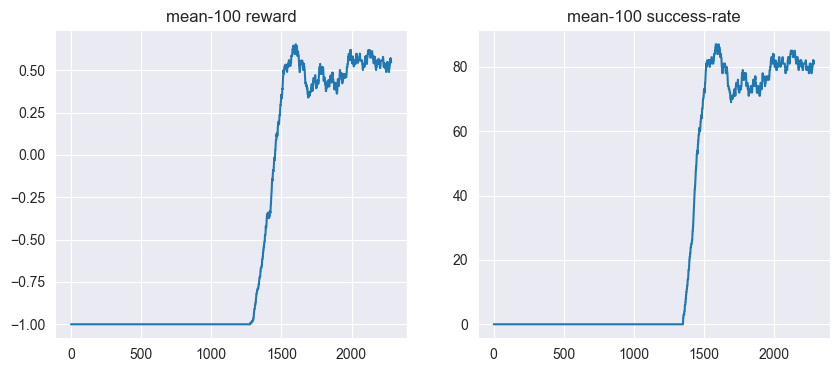

[Logger] dashboard saved ➜ runs/training_dashboard.png
[Logger] CSV saved ➜ runs/final_prioritized_log.csv
✅ CSV save function called
[Logger] numpy arrays saved ➜ runs/final_prioritized_arrays.npz
✅ NPZ save function called
✅ All logs saved.

==== Training finished ====
Success-rate     : 0.294
Collision-rate   : 0.693
Timeout-rate     : 0.014
Mean reward      : -0.394
Avg steps/ep     : 87.5
Saved files:
/Users/igornazarenko/PycharmProjects/FinalRL/runs/final_prioritized_log.csv
/Users/igornazarenko/PycharmProjects/FinalRL/runs/final_prioritized_arrays.npz
✅  final weights saved ➜  checkpoints/final_16x16_train_1753221230.pth


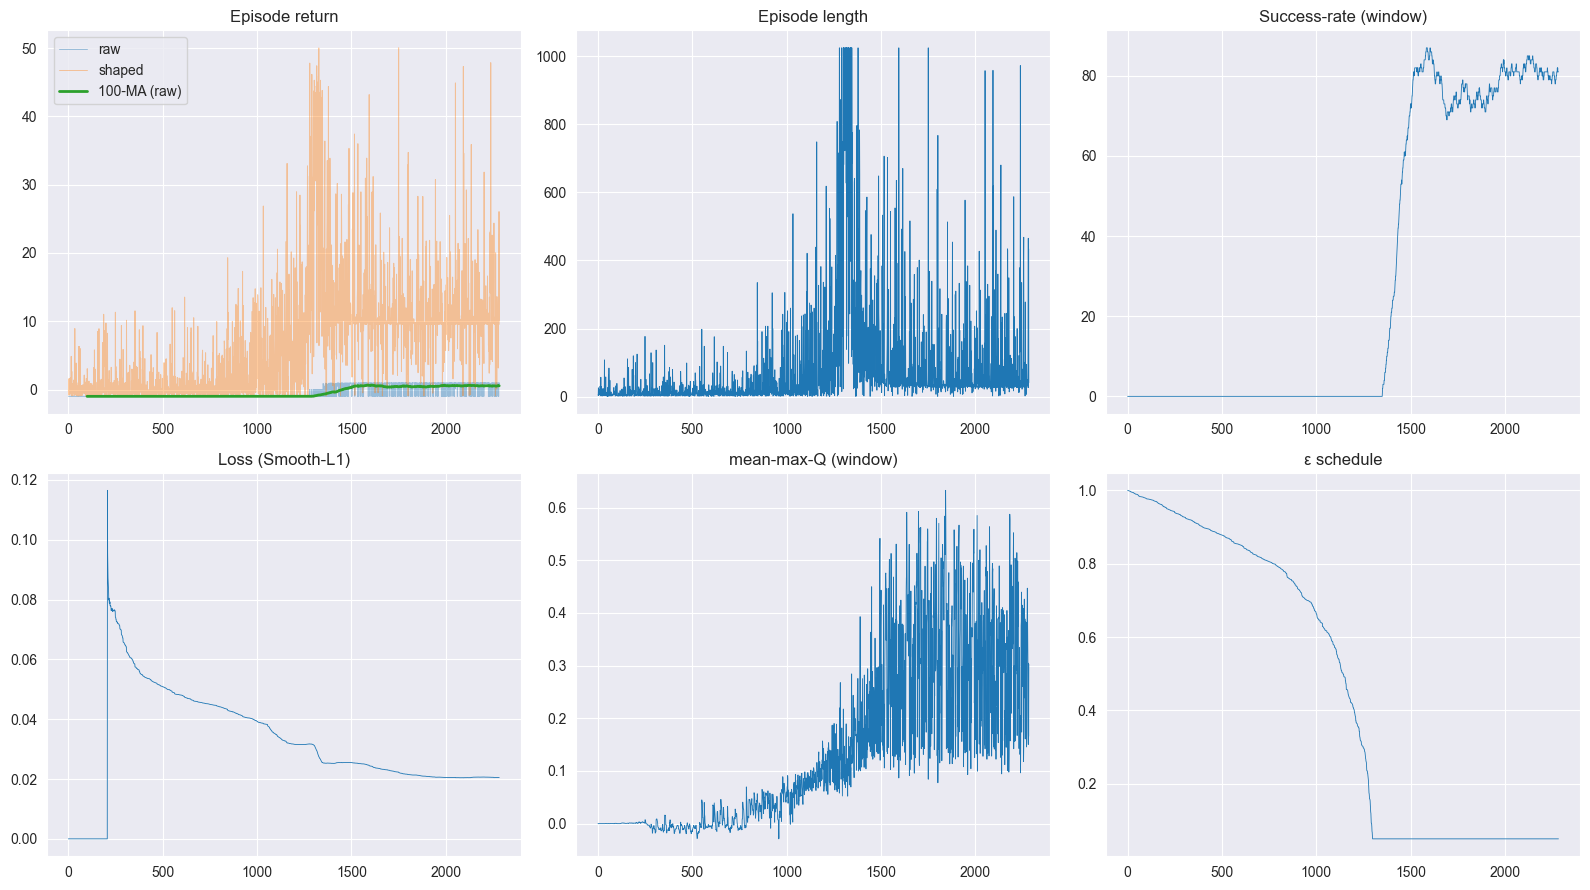

In [92]:
if __name__ == "__main__":
        # warm-start from the good 8×8 checkpoint
    main_train(
        size        ="16x16",
        max_steps   =200_000,     # give it time
        seq_len     =16,          # longer memory               ← optional tweak
        pretrained  ="final_16x16_train_1752762006.pth", # "checkpoints/drqn_8x8_1752673484.pth" or "final_16x16_train_1752762006.pth"
        strict_load =False,         # False if you later add dueling/etc.
        n_step=2,
        prioritized = True         # choose True for prioritized, False for uniform
    )

### 2: Stage C - Plotting different training curves

#### Loading 3 different training ararys:
1. Regular final arrays with PrioritizedRecurrentReplayBuffer and DuellingDRQN with 2 step TD.
2. uniform replay - RecurrentReplayBuffer instead of PrioritizedRecurrentReplayBuffer
    - in main_train and save that run to runs/uniform_*.
3. Shaping / bonus OFF
    - call main_train once more with
phi_coeff=0.0, beta_bonus=0.0, collision_scale=1.0.

In [29]:
def load(path):
    d = np.load(path, allow_pickle=True)
    hist = d["hist"].item()
    return {
        "steps": np.array(hist["step"]),
        "succ" : np.array(hist["success_rate"]),
        "ret"  : np.array(hist["mean100_reward"]),
        "pri_m": d.get("pri_mean", None),
        "isw_m": d.get("isw_mean", None),
        "isw_s": d.get("isw_std" , None),
    }

P  = load("runs/final_prioritized_arrays.npz")
U  = load("runs/final_uniform_arrays.npz")
NS = load("runs/final_noshaping_arrays.npz")

#### Figures 4.2, 4.3 – Training curves (A2C and DRQN) and DRQN diagnostics
- Figure 4.2:
    - Smoothed Success Rate (y-axis) vs. training steps (x-axis)
    - Smoothed Episode Length
    - Smoothed (Shaped and Unshaped Return) – stacked or overlaid
- Figure 4.3:
    - TD Loss curve (moving average)
    - Q-value distribution (histogram at end of training)

✓ saved figure_4_2.png
✓ saved figure_4_3.png


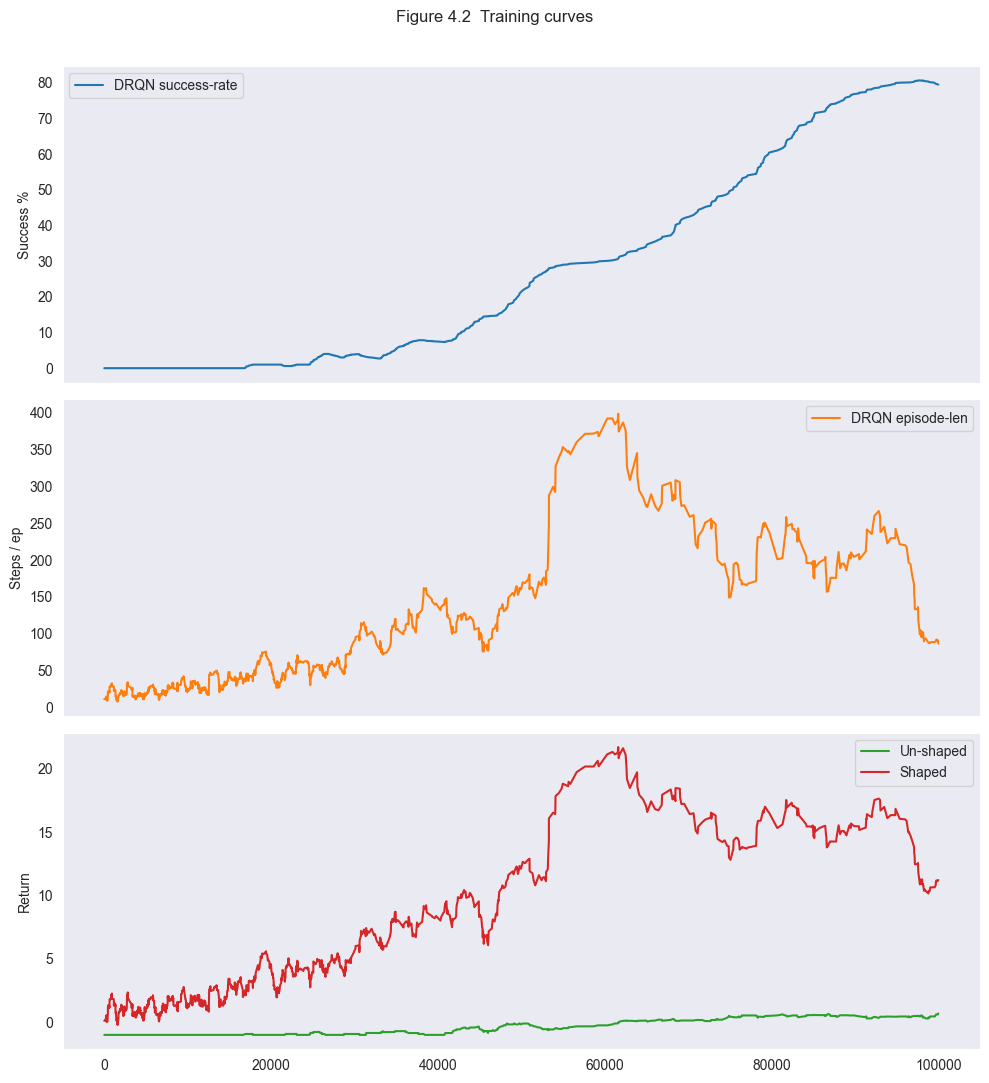

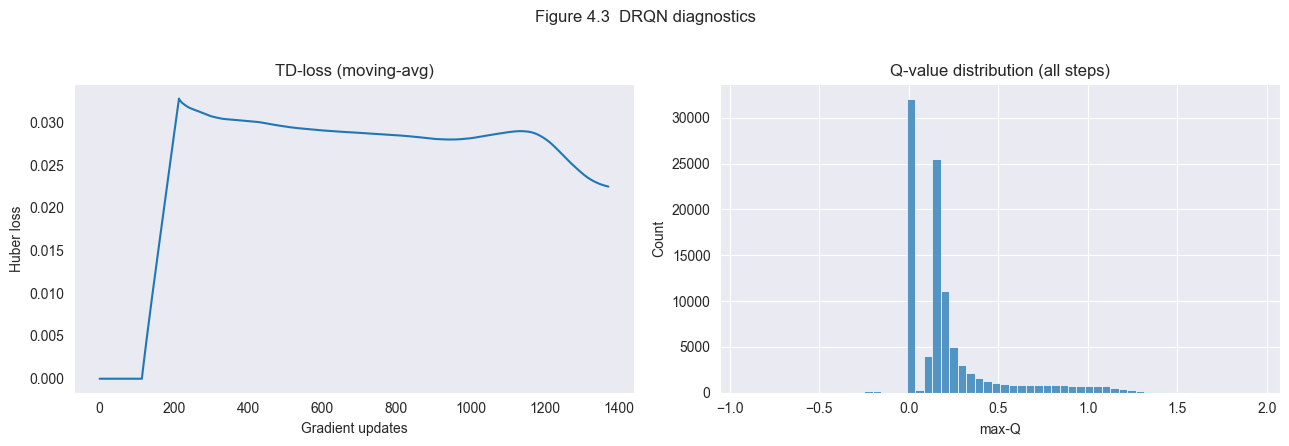

In [30]:
# ---------------------------------------------------------------
# Usage:
#   1. Put this cell in the same folder as  final_log.csv
#      and  final_arrays.npz   (or change RUN prefix below).
#   2. Run the cell – two PNGs will appear in the directory:
#        figure_4_2.png , figure_4_3.png
# ---------------------------------------------------------------
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.ndimage import uniform_filter1d

# ---------- helper ------------------------------------------------
def smooth(x, k=25):
    """cheap moving-average (reflect padding)"""
    return uniform_filter1d(x.astype(float), size=k, mode="nearest") if k>1 else x

def load_run(prefix, folder="."):
    csv_f = os.path.join(folder, f"{prefix}_log.csv")
    npz_f = os.path.join(folder, f"{prefix}_arrays.npz")
    if not (os.path.exists(csv_f) and os.path.exists(npz_f)):
        raise FileNotFoundError(f"Need both {csv_f} and {npz_f}")
    df   = pd.read_csv(csv_f)
    arrs = dict(np.load(npz_f, allow_pickle=True))
    # unwrap dict saved under 'hist'
    if isinstance(arrs.get("hist"), np.ndarray) and arrs["hist"].dtype==object:
        arrs["hist"] = arrs["hist"].item()
    return df, arrs

# ---------- main plotting routines --------------------------------
def fig_4_2(df, label="DRQN", k=25, out="figure_4_2.png"):
    steps = df["step"]
    fig, ax = plt.subplots(3,1,figsize=(10,11),sharex=True)

    ax[0].plot(steps, smooth(df["success_rate"],k), label=f"{label} success-rate")
    ax[0].set_ylabel("Success %"); ax[0].grid(); ax[0].legend()

    ax[1].plot(steps, smooth(df["ep_len"],k), c="tab:orange",
               label=f"{label} episode-len")
    ax[1].set_ylabel("Steps / ep"); ax[1].grid(); ax[1].legend()

    ax[2].plot(steps, smooth(df["ep_reward"],k),   c="tab:green", label="Un-shaped")
    if "ep_reward_shaped" in df.columns:
        ax[2].plot(steps, smooth(df["ep_reward_shaped"],k), c="tab:red", label="Shaped")
    ax[2].set_ylabel("Return"); ax[2].grid(); ax[2].legend()

    fig.suptitle("Figure 4.2  Training curves"); fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(out,dpi=150); print("✓ saved",out)

def fig_4_3(arrs, k=100, out="figure_4_3.png"):
    losses   = np.array(arrs.get("losses", []))
    q_vals   = np.array(arrs.get("q_samples", []))

    fig, ax = plt.subplots(1,2,figsize=(13,4.5))

    if losses.size:
        ax[0].plot(smooth(losses,k)); ax[0].set_title("TD-loss (moving-avg)")
        ax[0].set_xlabel("Gradient updates"); ax[0].set_ylabel("Huber loss"); ax[0].grid()
    else:
        ax[0].text(.5,.5,"losses not in NPZ",ha="center",va="center"); ax[0].axis("off")

    if q_vals.size:
        sns.histplot(q_vals,bins=60,ax=ax[1])
        ax[1].set_title("Q-value distribution (all steps)")
        ax[1].set_xlabel("max-Q"); ax[1].set_ylabel("Count")
    else:
        ax[1].text(.5,.5,"q_samples not in NPZ",ha="center",va="center"); ax[1].axis("off")

    fig.suptitle("Figure 4.3  DRQN diagnostics")
    fig.tight_layout(rect=[0,0,1,0.96]); fig.savefig(out,dpi=150); print("✓ saved",out)

# ---------- run ---------------------------------------------------
RUN = "final_prioritized"          # file stem:  final_log.csv / final_arrays.npz
FOLDER = "runs"               # directory that holds both files


df_run, arrs_run = load_run(RUN, folder=FOLDER)
fig_4_2(df_run, label="DRQN")     # Figure 4.2  → runs/figure_4_2.png
fig_4_3(arrs_run)                 # Figure 4.3  → runs/figure_4_3.png

#### Figure 4.4 – replay diagnostics

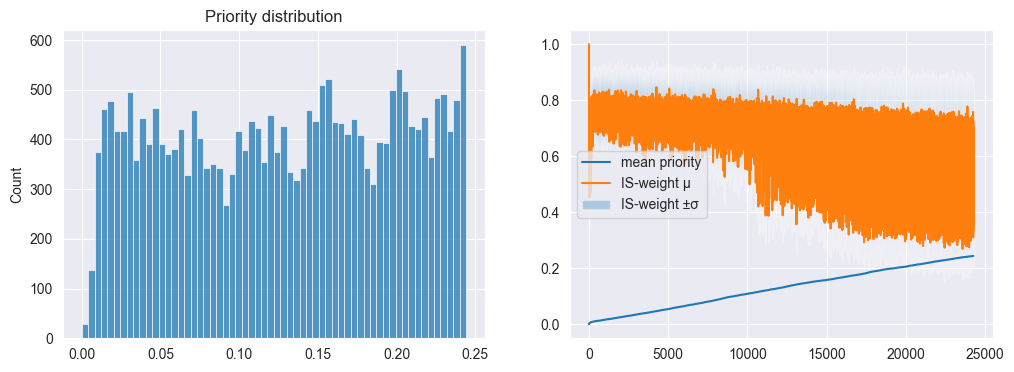

In [31]:
fig,ax = plt.subplots(1,2,figsize=(12,4))
sns.histplot(np.load("runs/final_prioritized_arrays.npz",
                     allow_pickle=True)["pri_mean"], bins=60, ax=ax[0])
ax[0].set_title("Priority distribution")
x = np.arange(len(P["pri_m"]))
ax[1].plot(x, P["pri_m"], label="mean priority")
ax[1].plot(x, P["isw_m"], label="IS-weight μ")
ax[1].fill_between(x, P["isw_m"] - P["isw_s"], P["isw_m"] + P["isw_s"],
                   alpha=.3, label="IS-weight ±σ")
ax[1].legend(); ax[1].grid(True)
fig.savefig("figure_4_4.png", dpi=150)

### Figure 4.5 – replay ablation

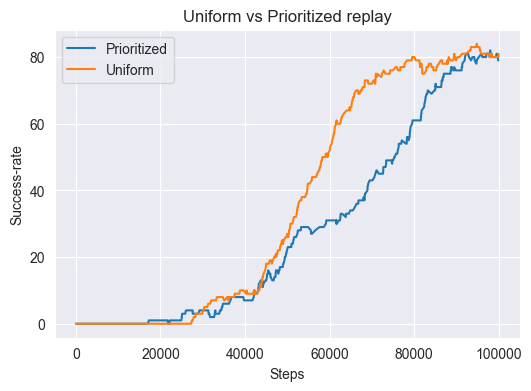

In [32]:
plt.figure(figsize=(6,4))
plt.plot(P["steps"], P["succ"], label="Prioritized")
plt.plot(U["steps"], U["succ"], label="Uniform")
plt.xlabel("Steps"); plt.ylabel("Success-rate")
plt.title("Uniform vs Prioritized replay"); plt.legend(); plt.grid(True)
plt.savefig("figure_4_5.png", dpi=150)

#### Figure 4.6 – shaping / bonus ablation

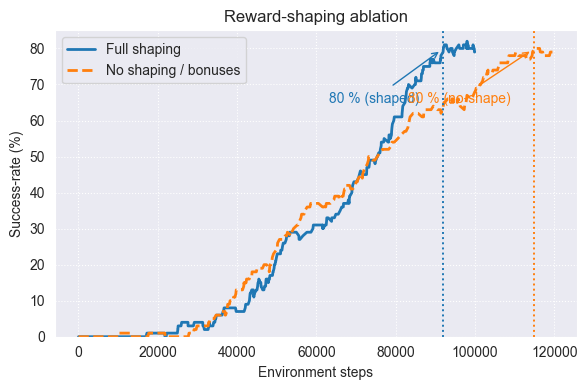

In [44]:
# ── helpers ─────────────────────────────────────────────
def first_reach_threshold(success_pct, threshold=80):
    """Return index where success_pct (0–100) first reaches threshold%."""
    idx = np.where(success_pct >= threshold)[0]
    return idx[0] if idx.size else None

def to_pct(arr):
    return arr * 100 if arr.max() <= 1.0 else arr

# ── series ──────────────────────────────────────────────
P_steps,  P_succ  = P["steps"],  to_pct(P["succ"])
NS_steps, NS_succ = NS["steps"], to_pct(NS["succ"])
thr = 80  # %

# ── plot ────────────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(P_steps,  P_succ,  lw=2, label="Full shaping",          color="tab:blue")
plt.plot(NS_steps, NS_succ, lw=2, label="No shaping / bonuses", color="tab:orange", ls="--")

# ----- helper for dashed line + label -------------------
def mark_threshold(x, label, color, xoff=-6_000, yoff=-12):
    plt.axvline(x, color=color, ls=":", lw=1.4)
    plt.annotate(label,
                 xy=(x, thr),                         # arrow target
                 xytext=(x + xoff, thr + yoff),       # text pos (←↓)
                 arrowprops=dict(arrowstyle="->", color=color,
                                 shrinkA=4, shrinkB=4),
                 color=color, ha="right", va="top")

# shaped
idx = first_reach_threshold(P_succ, thr)
if idx is not None:
    mark_threshold(P_steps[idx], "80 % (shaped)", "tab:blue")

# no-shape
idx = first_reach_threshold(NS_succ, thr)
if idx is not None:
    mark_threshold(NS_steps[idx], "80 % (no-shape)", "tab:orange")

# final-value text
plt.text(P_steps[-1],  P_succ[-1]  - 5, f"{P_succ[-1]:.1f} %",  color="tab:blue")
plt.text(NS_steps[-1], NS_succ[-1] - 9, f"{NS_succ[-1]:.1f} %", color="tab:orange")

# cosmetics
plt.xlabel("Environment steps")
plt.ylabel("Success-rate (%)")
plt.title("Reward-shaping ablation")
plt.grid(True, ls=":")
plt.legend()
plt.ylim(0, 85)
plt.tight_layout()
plt.savefig("figure_4_6.png", dpi=150)
plt.show()

### 3 - Evaluation Function after training

#### Helper function for the evaluation video - finding the 7*7 window

In [26]:
# ------------------------------------------------------------------
# Tiny helper: render full map and tint the agent’s 7×7 view
# ------------------------------------------------------------------
def render_with_view_tint(env, *, rgb=(0, 255, 0), alpha=0.25):
    """
    Returns an RGB frame where the agent’s current partial-obs window
    is lightly tinted (no split screen, no cv2 needed).
    """
    frame = env.render()                              # H×W×3 uint8
    H, W, _ = frame.shape
    gW, gH = env.unwrapped.width, env.unwrapped.height
    cell_w, cell_h = W / gW, H / gH

    topX, topY, botX, botY = env.unwrapped.get_view_exts()
    # --- NEW: ensure proper ordering -----------------------------
    if botX < topX: topX, botX = botX, topX
    if botY < topY: topY, botY = botY, topY
    # -------------------------------------------------------------

    # guarantee at least one grid-cell window
    if botX == topX: botX += 1
    if botY == topY: botY += 1

    # convert to pixel bounds
    x0 = int(np.floor(topX * cell_w))
    y0 = int(np.floor(topY * cell_h))
    x1 = int(np.ceil (botX * cell_w))
    y1 = int(np.ceil (botY * cell_h))

    # clip to frame
    x0, x1 = np.clip([x0, x1], 0, W)
    y0, y1 = np.clip([y0, y1], 0, H)


    # blend tint
    patch = frame[y0:y1, x0:x1].astype(np.float32)
    tint  = np.asarray(rgb, np.float32)
    blended = (1 - alpha) * patch + alpha * tint
    frame[y0:y1, x0:x1] = blended.astype(np.uint8)
    return frame

In [54]:
# ==============================================================
# Generic evaluation for DRQN / Dueling-DRQN checkpoints
# ==============================================================
@torch.no_grad()
def evaluate_drqn(
    ckpt_path : str,
    *,
    # --- optional overrides ------------------------------------
    size       : Optional[str]            = None,
    resize_to  : Optional[Tuple[int,int]] = None,
    n_stack    : Optional[int]            = None,
    device     = torch.device("cpu"),
    episodes   : int  = 100,              # ← default now 100
    tau        : float = 0.02,            # ← soft tie-break
    record     : bool  = False,           # save mp4s in ./videos
    render     : bool  = False,           # realtime window
    save_json  : Optional[str] = None,     # path to dump summary
    tint_rgb   = (0, 255, 0),             # green
    tint_alpha = 0.25
):
    """
    Evaluate a trained (Dueling)-DRQN agent with τ-greedy policy.
    records up to:
      • 3 success videos
      • 1 collision video
      • 1 timeout video
        with the agent's 7×7 partial-obs window highlighted in each frame.
    Returns
    -------
    summary : dict
        keys = {returns, lengths, succ_rate, coll_rate, timeout_rate,
                mean_return, mean_length}
    """
    # ---------- 1. load checkpoint (robust) --------------------
    torch.serialization.add_safe_globals([np.core.multiarray.scalar, np.dtype])
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    state_dict   = ckpt["model_state"]
    ckpt_size    = ckpt.get("size",      "16x16")
    ckpt_resize  = ckpt.get("resize_to", (64, 64))
    ckpt_stack   = 1                     # always 1 in your runs

    # allow CLI overrides
    size      = size      or ckpt_size
    resize_to = resize_to or ckpt_resize
    n_stack   = n_stack if n_stack is not None else ckpt_stack

    # ---------- recreate env  -------------------------------
    env = make_env(size, resize_to=resize_to, n_stack=n_stack, seed=42)

    if record or render:
        env.unwrapped.render_mode = "rgb_array"

    # ---------- rebuild net & load weights ------------------
    n_actions = env.action_space.n
    policy    = DuelingDRQN(env.observation_space, n_actions).to(device)
    policy.load_state_dict(state_dict, strict=True)
    policy.eval()

    # ---------- bookkeeping ---------------------------------
    returns, lengths = [], []
    succ = coll = tmo = 0

    # video-quota bookkeeping
    quota = {"succ": 3, "coll": 1, "tmo": 1}
    saved = {"succ": 0, "coll": 0, "tmo": 0}
    if record:
        os.makedirs("videos", exist_ok=True)

    # os.makedirs("videos", exist_ok=True)

    for ep in range(episodes):
        seed = np.random.randint(1e6)
        obs, _ = env.reset(seed=seed)
        h      = None
        done   = False
        ep_R   = 0.0

        # record frames *only* if any quota still open
        record_this = record and (sum(saved[v] < quota[v] for v in quota) > 0)
        frames = []  # allocate anyway (tiny) – grows only if record_this

        if record_this:   # capture frame 0
            frames.append(render_with_view_tint(env, rgb=tint_rgb, alpha=tint_alpha))

        while not done:
            if render: env.render()

            # τ-greedy action
            inp = torch.as_tensor(obs, device=device).unsqueeze(0).unsqueeze(0)
            q, h = policy(inp, h)
            q    = q[0, -1]                       # shape [n_actions]

            # -------- τ-greedy action selection ----------
            a_star  = int(q.argmax())
            second  = q.topk(2).values[1]
            if (q[a_star] - second) < tau:
                best_actions = (q >= q[a_star] - 1e-6).nonzero(as_tuple=True)[0]
                act = int(best_actions[torch.randint(len(best_actions), ())])
            else:
                act = a_star
            # --------------------------------------------

            obs, r, term, trunc, _ = env.step(act)
            done = term or trunc
            ep_R += r

            if record_this:
                frames.append(render_with_view_tint(env, rgb=tint_rgb, alpha=tint_alpha))

            # detach hidden state
            if h is not None:
                if isinstance(h, tuple):
                    h = (h[0].detach(), h[1].detach())
                else:
                    h = h.detach()

        # ------------ episode end ------------------------------
        returns.append(ep_R)
        lengths.append(env.unwrapped.step_count)

        if term and r > 0:
            outcome = "succ"
            succ += 1
        elif term and r < 0:
            outcome = "coll"
            coll += 1
        else:
            outcome = "tmo"
            tmo  += 1

        print(f"Ep {ep:02d} | {outcome.upper():4s} | R {ep_R:6.2f} | "
              f"steps {env.unwrapped.step_count:3d}")

        # -------- selective video saving -----------------------
        if record_this and saved[outcome] < quota[outcome]:
            fname = (f"videos/{os.path.basename(ckpt_path)[:-4]}_"
                     f"{outcome}_ep{ep:02d}.mp4")
            imageio.mimsave(fname, frames, fps=15)
            saved[outcome] += 1
            print(f"  • video saved → {fname}")

    env.close()

    # ---------- summary & return ----------------------------
    summary = {
        "episodes"     : episodes,
        "returns"      : np.array(returns),
        "lengths"      : np.array(lengths),
        "succ_rate"    : succ / episodes,
        "coll_rate"    : coll / episodes,
        "timeout_rate" : tmo  / episodes,
        "mean_return"  : float(np.mean(returns)),
        "mean_length"  : float(np.mean(lengths)),
    }

    # quick sanity-check
    total_frac = summary["succ_rate"] + summary["coll_rate"] + summary["timeout_rate"]
    assert abs(total_frac - 1.0) < 1e-6, "Outcome fractions don't sum to 1!"

    if save_json:
        import json, pathlib
        pathlib.Path(save_json).parent.mkdir(parents=True, exist_ok=True)
        with open(save_json, "w") as f:
            json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v)
                       for k, v in summary.items()}, f, indent=2)
        print(f"Summary saved → {save_json}")

    return summary

#### Applying the evaluation:

In [55]:
if __name__ == "__main__":
    summary = evaluate_drqn(
        ckpt_path = "checkpoints/duel16_best_overall_0.82.pth",
        episodes  = 100,          # can omit; now default
        size      = "16x16",      # override if you want
        device    = torch.device(device),
        tau       = 0.02,
        record    = True,         # saves mp4s
        render    = False,
        save_json = "eval_logs/DRQN_eval.json"
    )

Ep 00 | SUCC | R   0.90 | steps 118
  • video saved → videos/duel16_best_overall_0.82_succ_ep00.mp4
Ep 01 | SUCC | R   0.97 | steps  31
  • video saved → videos/duel16_best_overall_0.82_succ_ep01.mp4
Ep 02 | SUCC | R   0.96 | steps  41
  • video saved → videos/duel16_best_overall_0.82_succ_ep02.mp4
Ep 03 | SUCC | R   0.97 | steps  39
Ep 04 | SUCC | R   0.96 | steps  50
Ep 05 | SUCC | R   0.97 | steps  29
Ep 06 | SUCC | R   0.97 | steps  29
Ep 07 | SUCC | R   0.97 | steps  29
Ep 08 | SUCC | R   0.97 | steps  29
Ep 09 | SUCC | R   0.91 | steps  98
Ep 10 | SUCC | R   0.93 | steps  76
Ep 11 | SUCC | R   0.97 | steps  29
Ep 12 | SUCC | R   0.96 | steps  45
Ep 13 | SUCC | R   0.97 | steps  31
Ep 14 | SUCC | R   0.95 | steps  52
Ep 15 | SUCC | R   0.93 | steps  81
Ep 16 | SUCC | R   0.95 | steps  57
Ep 17 | SUCC | R   0.90 | steps 113
Ep 18 | SUCC | R   0.97 | steps  38
Ep 19 | SUCC | R   0.96 | steps  51
Ep 20 | SUCC | R   0.92 | steps  90
Ep 21 | SUCC | R   0.97 | steps  29
Ep 22 | SUCC | R